## Visualisation

In [10]:
import matplotlib.pyplot as plt
import time

In [9]:
import numpy as np

# Make sure to use exactly these variable names:
freemoves_X = np.load('freemoves_dataset_X.npy')
freemoves_y = np.load('freemoves_dataset_y.npy')
freemoves_testset_X = np.load('freemoves_testset_X.npy')

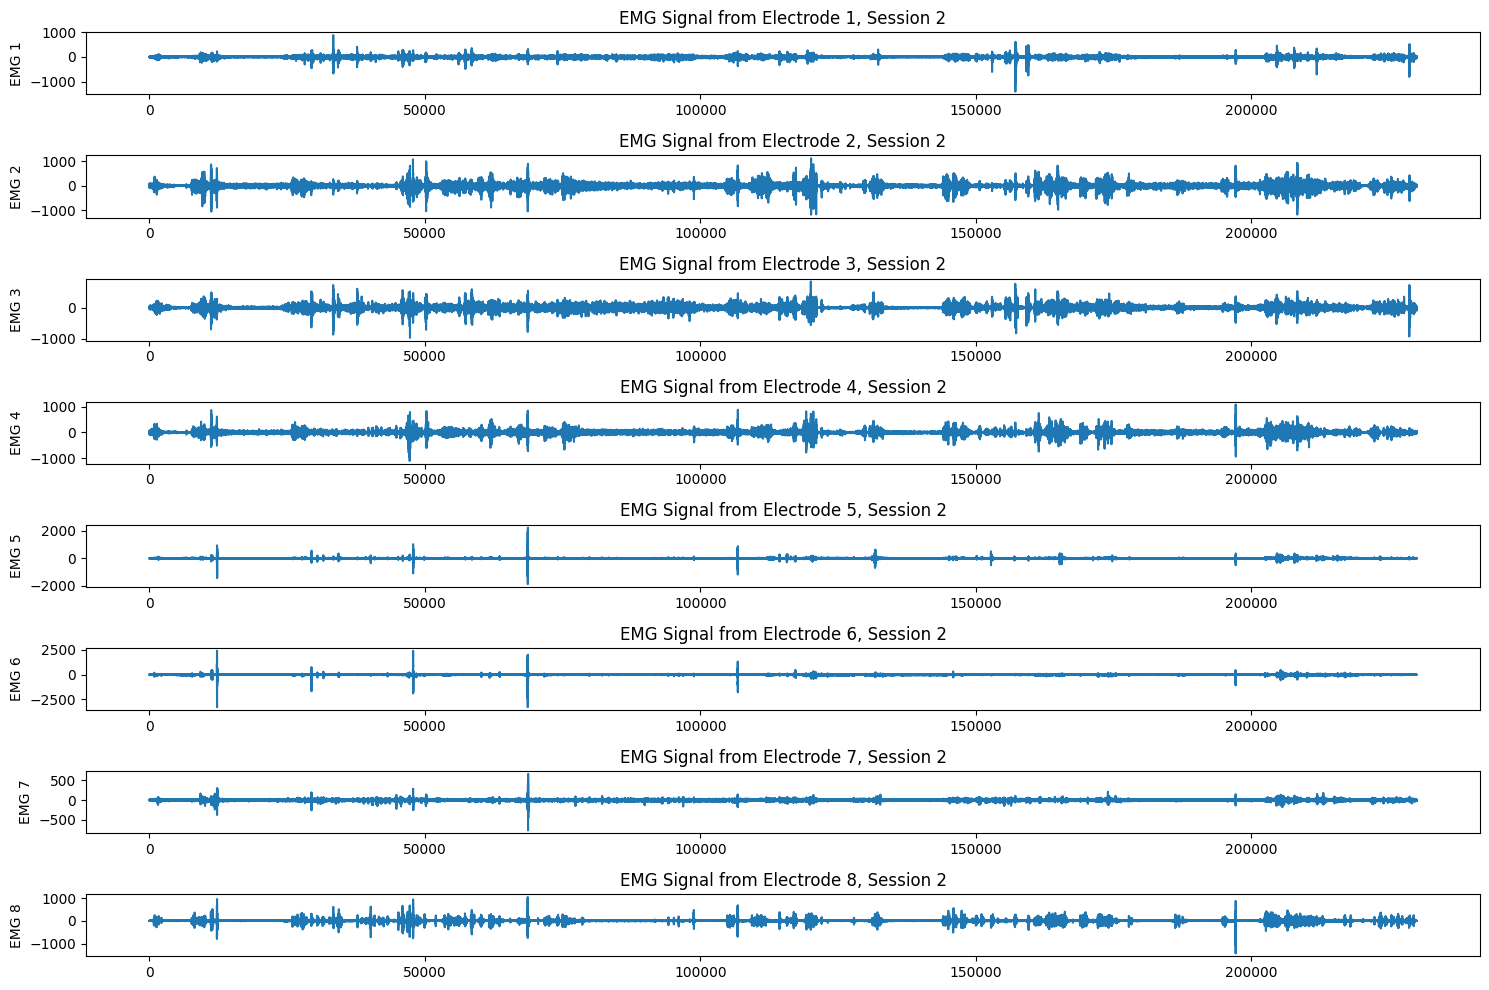

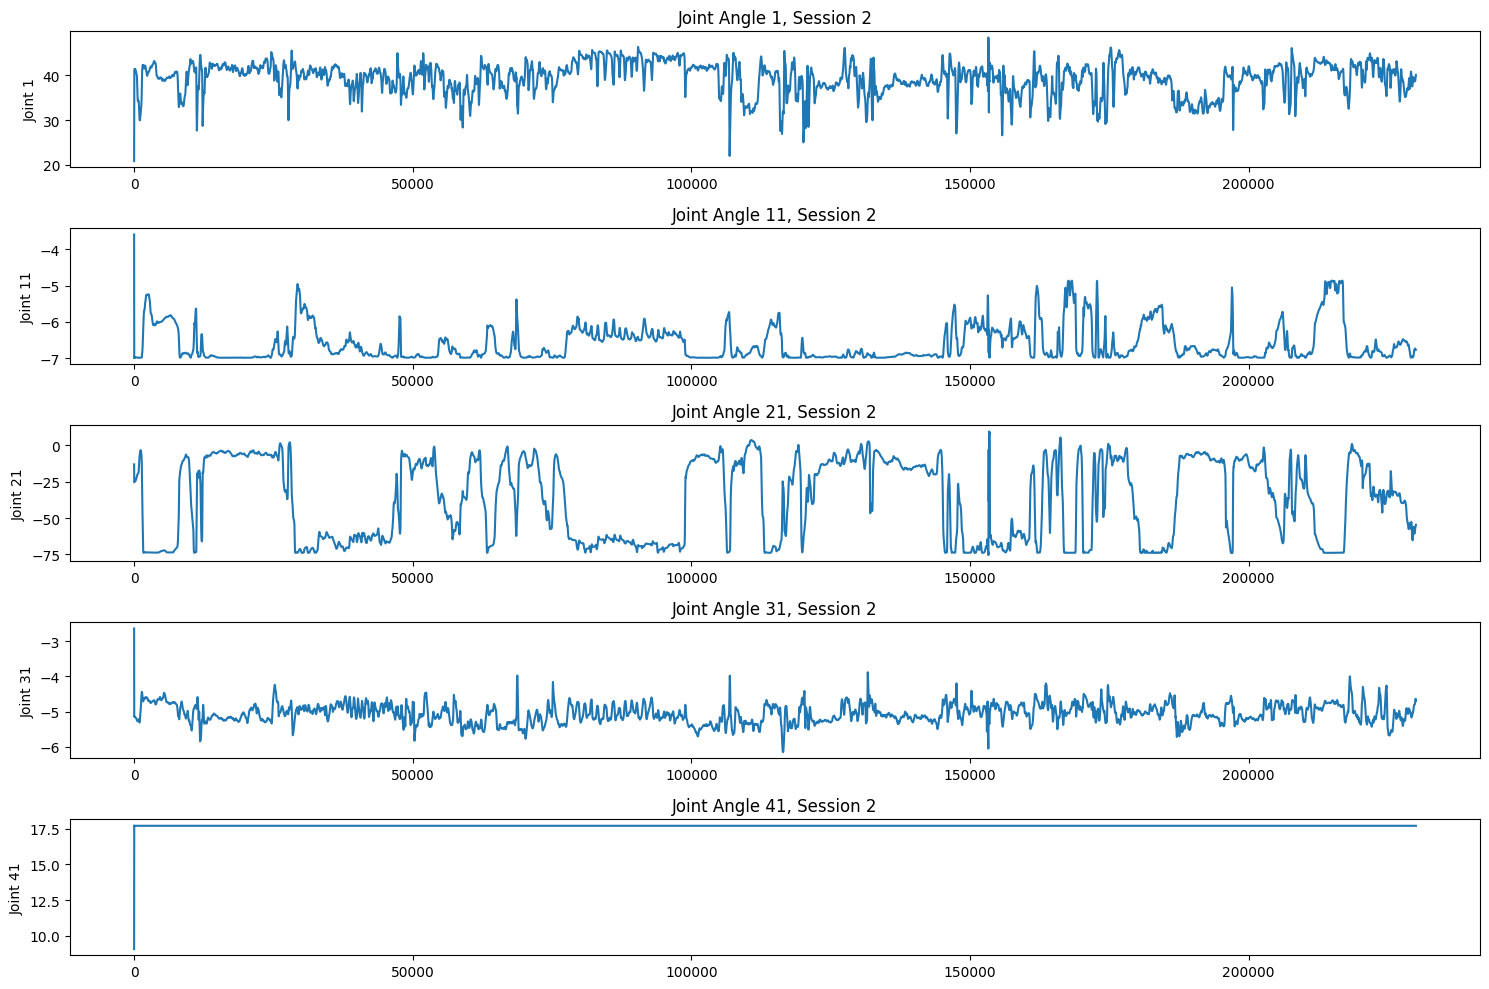

In [11]:

# Let's examine one session
session_id = 1

# Plot EMG signals from all 8 electrodes for a short time segment
plt.figure(figsize=(15, 10))
time_segment = slice(0, 230000)  # First 5000 samples (about 5 seconds at 1024 Hz)

for electrode in range(8):
    plt.subplot(8, 1, electrode+1)
    plt.plot(freemoves_X[session_id, electrode, time_segment])
    plt.ylabel(f'EMG {electrode+1}')
    plt.title(f'EMG Signal from Electrode {electrode+1}, Session {session_id+1}')
    
plt.tight_layout()
plt.show()

# Plot a few joint angles for the same time segment
plt.figure(figsize=(15, 10))
for i, joint_id in enumerate([0, 10, 20, 30, 40]):  # Sample a few joints
    plt.subplot(5, 1, i+1)
    plt.plot(freemoves_y[session_id, joint_id, time_segment])
    plt.ylabel(f'Joint {joint_id+1}')
    plt.title(f'Joint Angle {joint_id+1}, Session {session_id+1}')
    
plt.tight_layout()
plt.show()

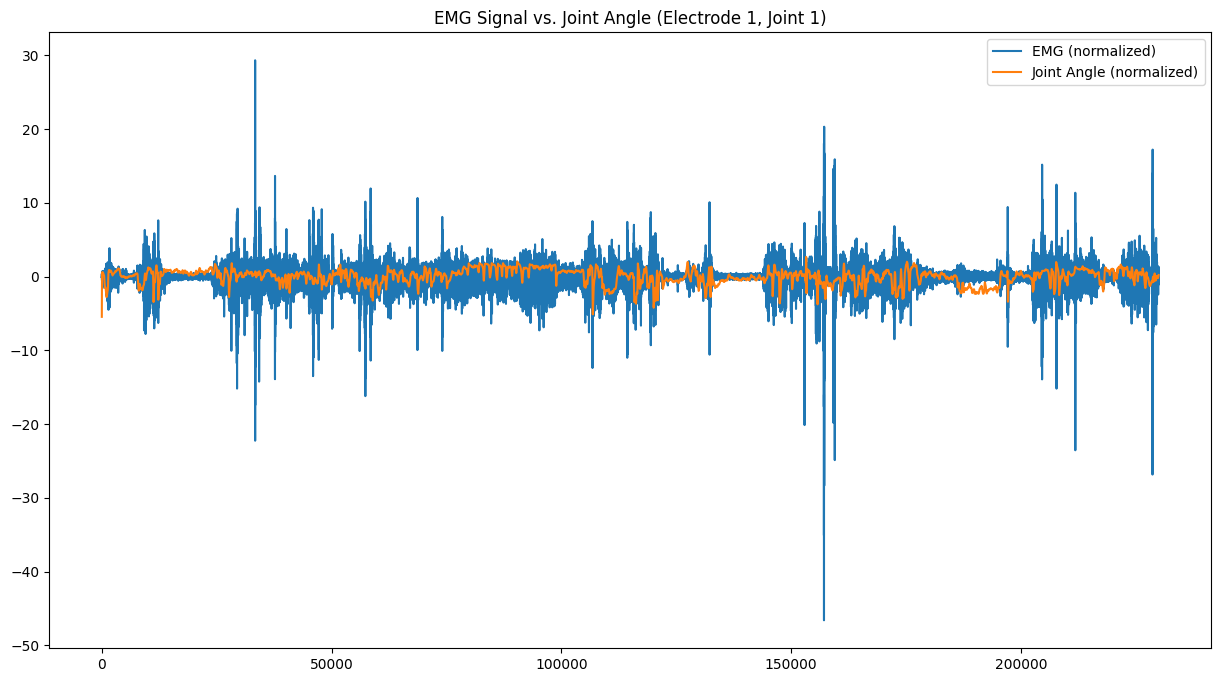

In [12]:
# Pick a short segment to visualize the relationship
plt.figure(figsize=(15, 8))

# Choose one electrode and one joint angle to visualize
electrode_id = 0
joint_id = 0
time_segment = slice(0, 230000)

# Normalize both signals for better visualization
emg_signal = freemoves_X[session_id, electrode_id, time_segment]
joint_angle = freemoves_y[session_id, joint_id, time_segment]

emg_normalized = (emg_signal - np.mean(emg_signal)) / np.std(emg_signal)
joint_normalized = (joint_angle - np.mean(joint_angle)) / np.std(joint_angle)

plt.plot(emg_normalized, label='EMG (normalized)')
plt.plot(joint_normalized, label='Joint Angle (normalized)')
plt.legend()
plt.title(f'EMG Signal vs. Joint Angle (Electrode {electrode_id+1}, Joint {joint_id+1})')
plt.show()

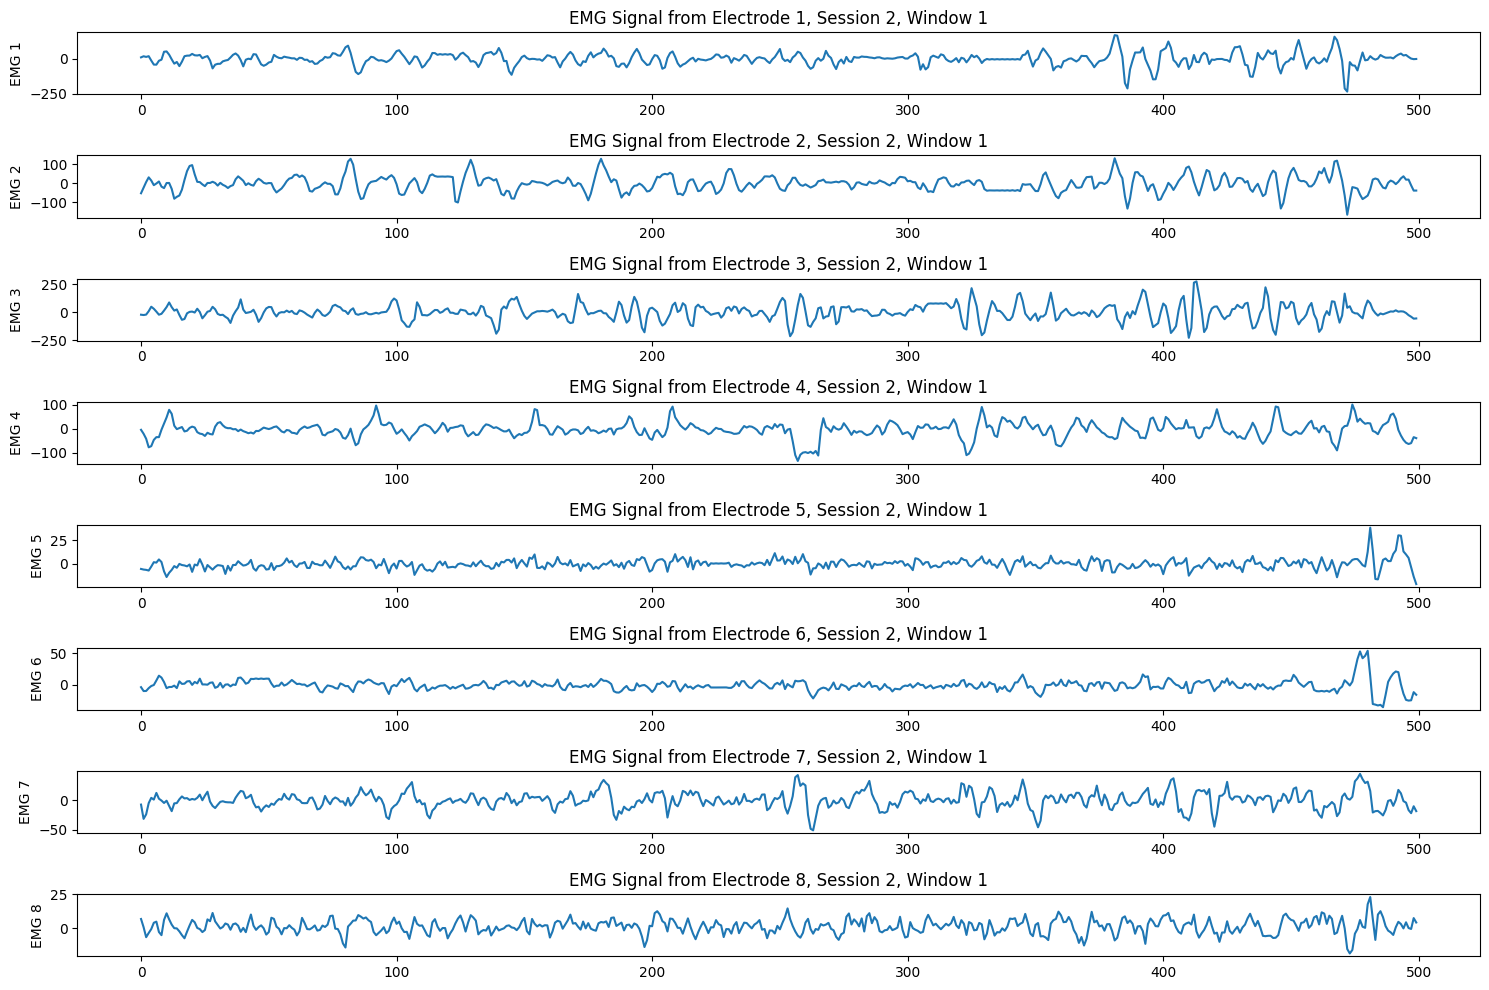

In [13]:
# Examine the test data
window_id = 0

# Plot EMG signals from one window
plt.figure(figsize=(15, 10))
for electrode in range(8):
    plt.subplot(8, 1, electrode+1)
    plt.plot(freemoves_testset_X[session_id, window_id, electrode, :])
    plt.ylabel(f'EMG {electrode+1}')
    plt.title(f'EMG Signal from Electrode {electrode+1}, Session {session_id+1}, Window {window_id+1}')
    
plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create windows with overlap
def create_windows_with_overlap(data, window_size=500, overlap_percent=50):
    """
    Create overlapping windows from continuous EMG data.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Input data with shape (session, electrode/joint, time)
    window_size : int
        Size of each window in samples
    overlap_percent : float
        Percentage of overlap between consecutive windows (0-100)
    
    Returns:
    --------
    windows : numpy.ndarray
        Windowed data with shape (n_windows_total, electrode/joint, window_size)
    window_indices : list of tuples
        List containing (session_idx, window_start_idx, window_end_idx) for each window
    """
    n_sessions, n_channels, n_samples = data.shape
    
    # Calculate step size based on overlap percentage
    step_size = int(window_size * (1 - overlap_percent/100))
    
    windows = []
    window_indices = []
    
    # Process each session separately
    for session_idx in range(n_sessions):
        # Calculate how many windows we can extract from this session
        n_windows = 1 + (n_samples - window_size) // step_size
        
        for window_idx in range(n_windows):
            # Calculate start and end indices
            start_idx = window_idx * step_size
            end_idx = start_idx + window_size
            
            # Make sure we don't exceed the data length
            if end_idx <= n_samples:
                # Extract window for all channels
                window = data[session_idx, :, start_idx:end_idx]
                windows.append(window)
                window_indices.append((session_idx, start_idx, end_idx))
    
    # Convert list of windows to numpy array
    windows = np.array(windows)
    
    return windows, window_indices

def extract_time_domain_features(window):
    """
    Extract common time-domain features from a window of EMG data.
    
    Parameters:
    -----------
    window : numpy.ndarray
        Window of EMG data with shape (n_channels, window_size)
    
    Returns:
    --------
    features : numpy.ndarray
        Feature vector with shape (n_channels * n_features,)
    """
    n_channels, window_size = window.shape
    features = []
    
    for channel in range(n_channels):
        channel_data = window[channel, :]
        
        # Mean Absolute Value (MAV)
        mav = np.mean(np.abs(channel_data))
        
        # Root Mean Square (RMS)
        rms = np.sqrt(np.mean(channel_data**2))
        
        # Variance
        var = np.var(channel_data)
        
        # Standard Deviation
        std = np.std(channel_data)
        
        # Zero Crossing (ZC)
        zc = np.sum(np.diff(np.signbit(channel_data).astype(int)) != 0)
        
        # Myopulse Percentage Rate (MPR)
        threshold = np.std(channel_data)
        mpr = np.mean(np.abs(channel_data) > threshold)
        
        # Add all features for this channel
        channel_features = [mav, rms, var, std, zc, mpr]
        features.extend(channel_features)
    
    return np.array(features)

# Create windows
X_windows, X_indices = create_windows_with_overlap(freemoves_X, window_size=500, overlap_percent=75)
y_windows, y_indices = create_windows_with_overlap(freemoves_y, window_size=500, overlap_percent=75)

# Extract features for all windows
X_features = np.array([extract_time_domain_features(window) for window in X_windows])

# Visualize one window and its features
window_idx = 10  # Choose a window to visualize

# Create figure with GridSpec for better layout
fig = plt.figure(figsize=(18, 15))
gs = GridSpec(3, 2, figure=fig)

print(f"Original data shape: {freemoves_X.shape}")
print(f"Windowed data shape: {X_windows.shape}")
print(f"Number of windows per session (approx): {len(X_indices) // 5}")

Original data shape: (5, 8, 270000)
Windowed data shape: (10785, 8, 500)
Number of windows per session (approx): 2157


<Figure size 1800x1500 with 0 Axes>

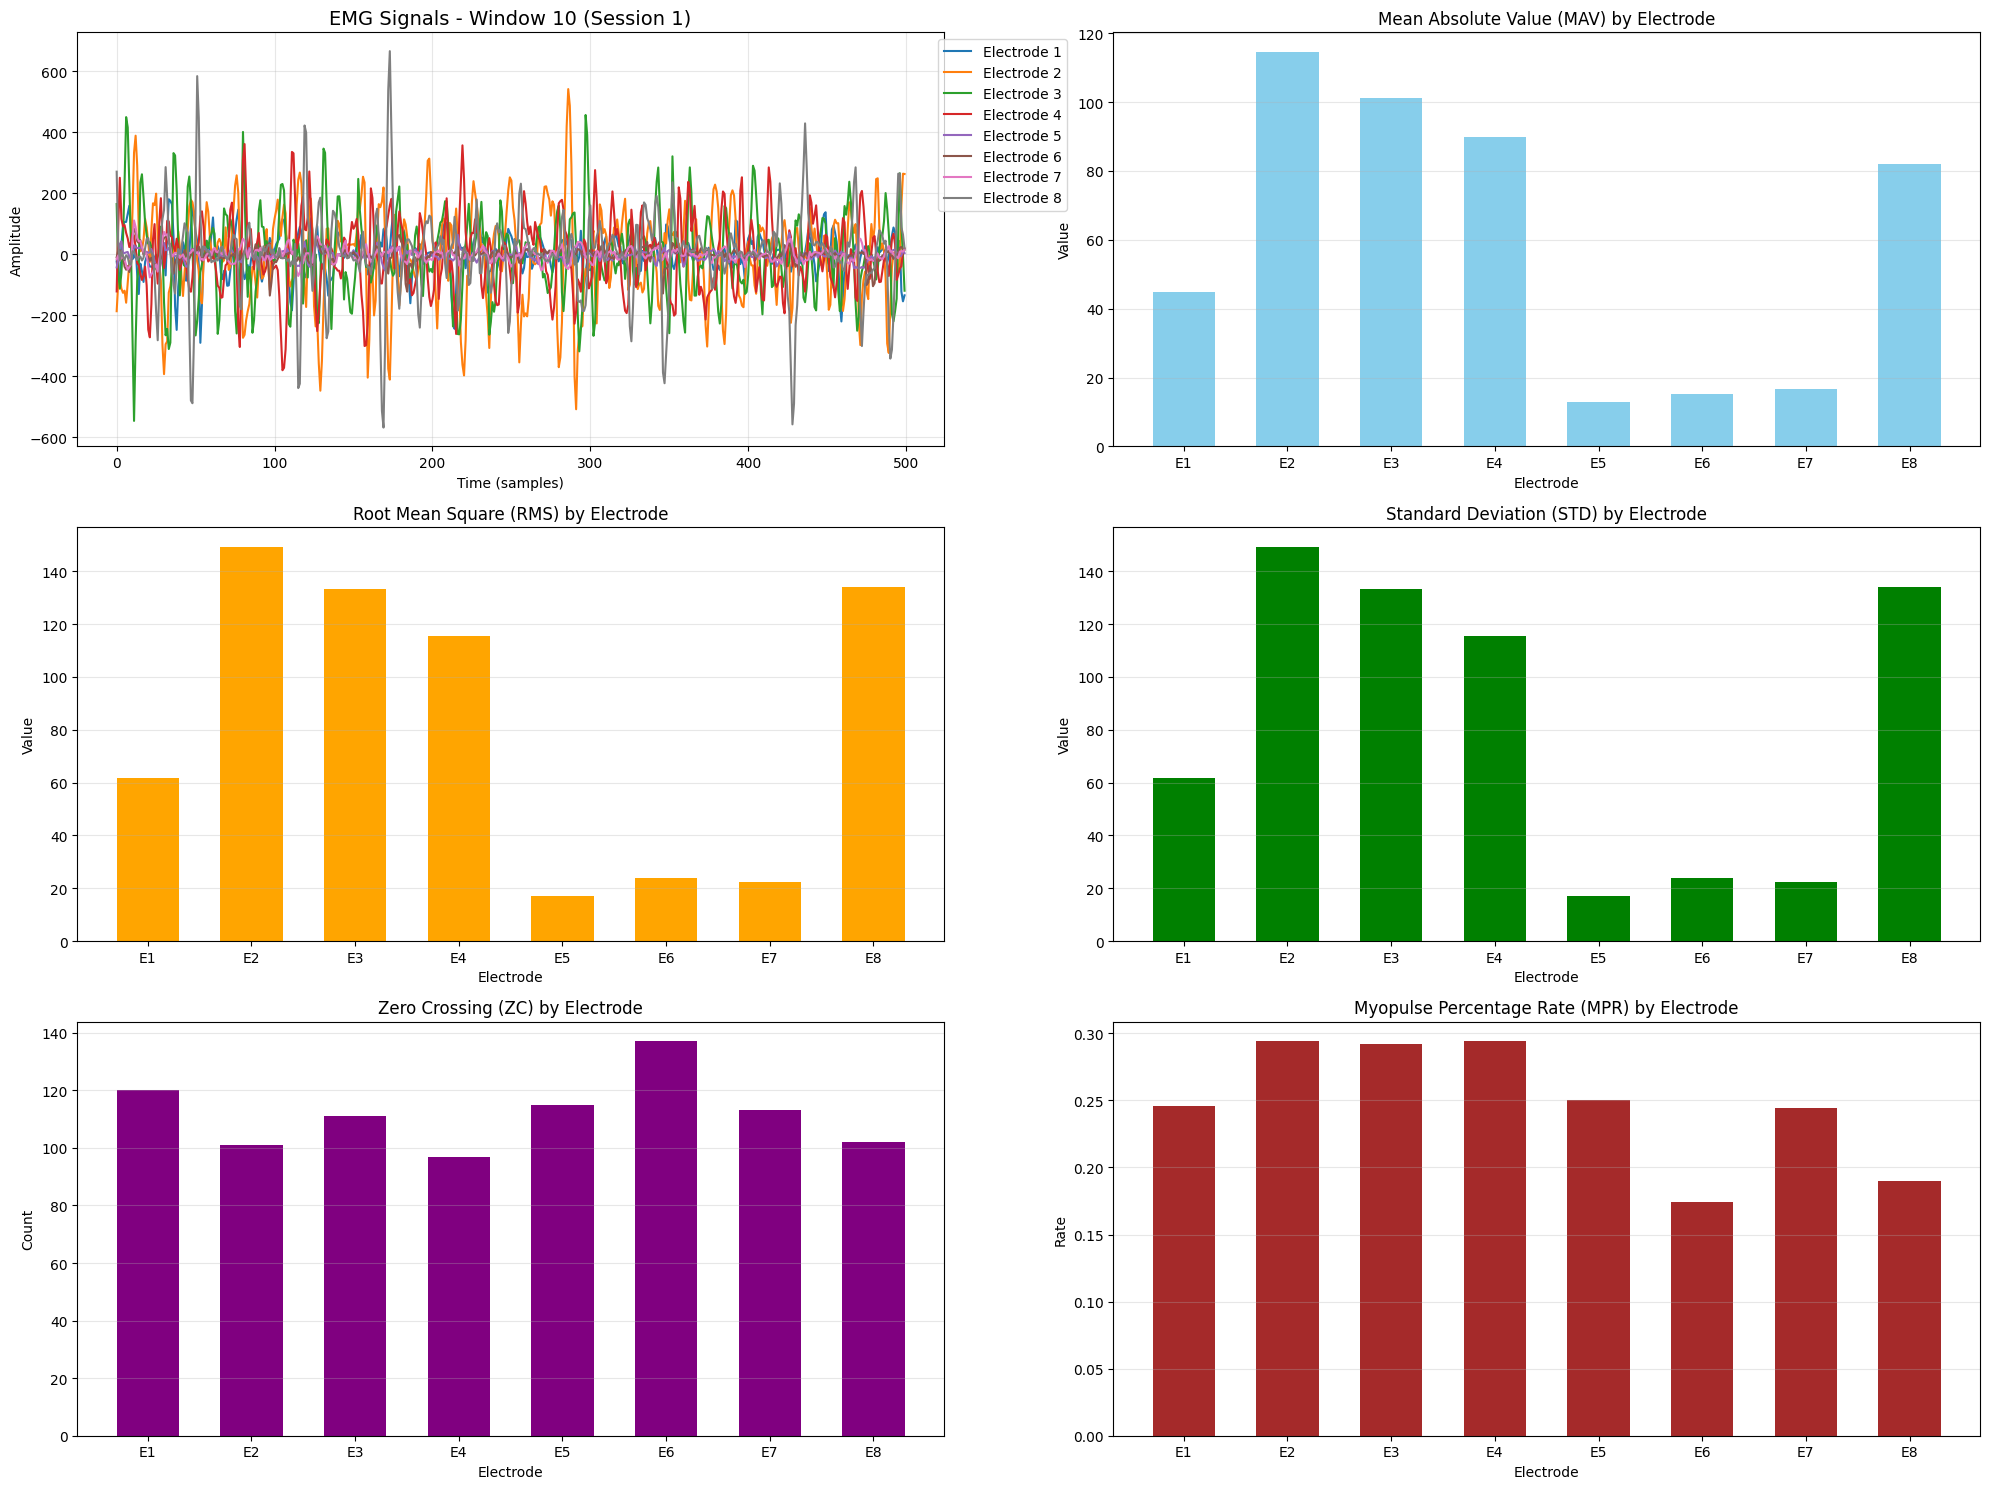

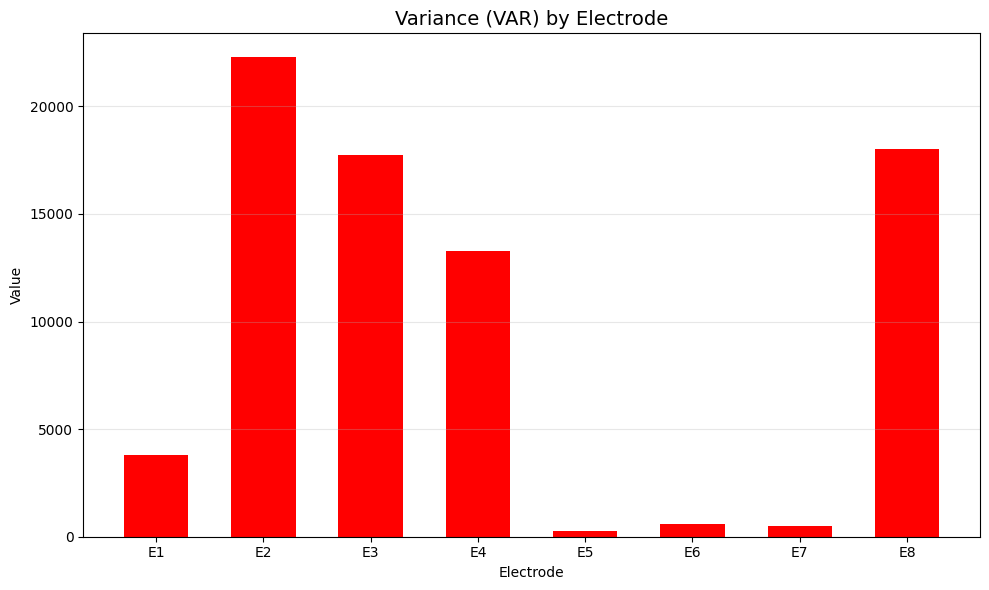

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure with a proper grid of subplots
fig = plt.figure(figsize=(20, 15))

# Plot the EMG data for this window
ax1 = plt.subplot(3, 2, 1)
for channel in range(X_windows.shape[1]):
    ax1.plot(X_windows[window_idx, channel, :], label=f'Electrode {channel+1}')
ax1.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax1.set_title(f'EMG Signals - Window {window_idx} (Session {X_indices[window_idx][0]+1})', fontsize=14)
ax1.set_xlabel('Time (samples)')
ax1.set_ylabel('Amplitude')
ax1.grid(True, alpha=0.3)

# Reshape features for visualization
feature_names = ['MAV', 'RMS', 'VAR', 'STD', 'ZC', 'MPR']
n_channels = X_windows.shape[1]
n_features = len(feature_names)
features = X_features[window_idx].reshape(n_channels, n_features)

# Plot MAV
ax2 = plt.subplot(3, 2, 2)
ax2.bar(np.arange(n_channels), features[:, 0], color='skyblue', width=0.6)
ax2.set_title('Mean Absolute Value (MAV) by Electrode', fontsize=12)
ax2.set_xlabel('Electrode')
ax2.set_ylabel('Value')
ax2.set_xticks(np.arange(n_channels))
ax2.set_xticklabels([f'E{i+1}' for i in range(n_channels)])
ax2.grid(True, alpha=0.3, axis='y')

# Plot RMS
ax3 = plt.subplot(3, 2, 3)
ax3.bar(np.arange(n_channels), features[:, 1], color='orange', width=0.6)
ax3.set_title('Root Mean Square (RMS) by Electrode', fontsize=12)
ax3.set_xlabel('Electrode')
ax3.set_ylabel('Value')
ax3.set_xticks(np.arange(n_channels))
ax3.set_xticklabels([f'E{i+1}' for i in range(n_channels)])
ax3.grid(True, alpha=0.3, axis='y')

# Plot STD (not VAR, to keep scale more manageable)
ax4 = plt.subplot(3, 2, 4)
ax4.bar(np.arange(n_channels), features[:, 3], color='green', width=0.6)
ax4.set_title('Standard Deviation (STD) by Electrode', fontsize=12)
ax4.set_xlabel('Electrode')
ax4.set_ylabel('Value')
ax4.set_xticks(np.arange(n_channels))
ax4.set_xticklabels([f'E{i+1}' for i in range(n_channels)])
ax4.grid(True, alpha=0.3, axis='y')

# Plot ZC
ax5 = plt.subplot(3, 2, 5)
ax5.bar(np.arange(n_channels), features[:, 4], color='purple', width=0.6)
ax5.set_title('Zero Crossing (ZC) by Electrode', fontsize=12)
ax5.set_xlabel('Electrode')
ax5.set_ylabel('Count')
ax5.set_xticks(np.arange(n_channels))
ax5.set_xticklabels([f'E{i+1}' for i in range(n_channels)])
ax5.grid(True, alpha=0.3, axis='y')

# Plot MPR
ax6 = plt.subplot(3, 2, 6)
ax6.bar(np.arange(n_channels), features[:, 5], color='brown', width=0.6)
ax6.set_title('Myopulse Percentage Rate (MPR) by Electrode', fontsize=12)
ax6.set_xlabel('Electrode')
ax6.set_ylabel('Rate')
ax6.set_xticks(np.arange(n_channels))
ax6.set_xticklabels([f'E{i+1}' for i in range(n_channels)])
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('improved_features_visualization.png', dpi=300)
plt.show()

# Separately plot VAR (since it has a very different scale)
plt.figure(figsize=(10, 6))
plt.bar(np.arange(n_channels), features[:, 2], color='red', width=0.6)
plt.title('Variance (VAR) by Electrode', fontsize=14)
plt.xlabel('Electrode')
plt.ylabel('Value')
plt.xticks(np.arange(n_channels), [f'E{i+1}' for i in range(n_channels)])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('variance_feature.png', dpi=300)
plt.show()

## Main

In [1]:
import numpy as np

# Make sure to use exactly these variable names:
freemoves_X = np.load('freemoves_dataset_X.npy')
freemoves_y = np.load('freemoves_dataset_y.npy')
freemoves_testset_X = np.load('freemoves_testset_X.npy')

In [2]:
import matplotlib.pyplot as plt
import time
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import RFECV

#--------------------------------------------------------------
# 1. Data Preprocessing & Signal filtering
#--------------------------------------------------------------

def preprocess_emg_data(X_data, apply_filtering=True, normalize=True, visualize=False,
                     session_id=0, electrode_id=0, time_segment=slice(0, 5000)):
    """
    Preprocess EMG data by applying filtering and normalization
    
    Parameters:
    -----------
    X_data : numpy.ndarray
        Input EMG data with shape (session, electrode, time) or 
        (n_windows, electrode, window_size)
    apply_filtering : bool
        Whether to apply bandpass and notch filtering to the signals
    normalize : bool
        Whether to normalize each channel to zero mean and unit variance
    visualize : bool
        Whether to visualize the original and filtered signals
    session_id : int
        Session ID to visualize (if visualize=True)
    electrode_id : int
        Electrode ID to visualize (if visualize=True)
    time_segment : slice
        Time segment to visualize (if visualize=True)
        
    Returns:
    --------
    processed_data : numpy.ndarray
        Preprocessed EMG data with the same shape as input
    """
    import numpy as np
    from scipy.signal import butter, filtfilt, iirnotch
    import matplotlib.pyplot as plt
    
    # Store the original shape to reshape at the end
    original_shape = X_data.shape
    original_data = X_data.copy()  # Keep a copy for visualization
    
    # Handle different input shapes
    if len(original_shape) == 3:
        if original_shape[0] <= 10:  # Likely (session, electrode, time)
            n_sessions, n_electrodes, n_samples = original_shape
            data_to_process = X_data.copy()
        else:  # Likely (n_windows, electrode, window_size)
            n_windows, n_electrodes, window_size = original_shape
            # Reshape to 3D for consistent processing
            data_to_process = X_data.reshape(1, n_electrodes, -1)
            n_sessions = 1
    elif len(original_shape) == 4:  # (session, window, electrode, time)
        n_sessions, n_windows, n_electrodes, window_size = original_shape
        # Reshape to 3D for processing
        data_to_process = X_data.reshape(n_sessions, n_electrodes, -1)
    else:
        raise ValueError(f"Unexpected input shape: {original_shape}")
    
    # Initialize the output array
    processed_data = np.zeros_like(data_to_process)
    
    # Apply filtering if requested
    if apply_filtering:
        print("Applying bandpass and notch filters to EMG signals...")
        # EMG bandpass filter settings (20-450 Hz)
        fs = 1024  # Sampling frequency in Hz
        lowcut = 20  # High-pass to remove motion artifacts
        highcut = 450  # Low-pass to remove high frequency noise or 500
        
        # Notch filter at 50Hz to remove power line interference
        notch_freq = 50
        quality_factor = 30  # Q factor determines notch width
        
        # Create bandpass filter
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b_band, a_band = butter(4, [low, high], btype='band')
        
        # Create notch filter
        b_notch, a_notch = iirnotch(notch_freq, quality_factor, fs)
        
        # Apply filters to each session and electrode
        for session in range(n_sessions):
            for electrode in range(n_electrodes):
                # First apply bandpass
                temp = filtfilt(b_band, a_band, data_to_process[session, electrode, :])
                # Then apply notch
                processed_data[session, electrode, :] = filtfilt(b_notch, a_notch, temp)
    else:
        processed_data = data_to_process.copy()
    
    # Check for and handle NaN or infinity values
    if np.any(~np.isfinite(processed_data)):
        print("Warning: NaN or infinity values detected in the data. Replacing with zeros.")
        processed_data[~np.isfinite(processed_data)] = 0
    
    # Normalize each channel if requested
    if normalize:
        print("Normalizing EMG channels...")
        for session in range(n_sessions):
            for electrode in range(n_electrodes):
                channel_data = processed_data[session, electrode, :]
                # Z-score normalization (zero mean, unit variance)
                mean = np.mean(channel_data)
                std = np.std(channel_data)
                if std > 0:  # Avoid division by zero
                    processed_data[session, electrode, :] = (channel_data - mean) / std
    
    # Visualize if requested
    if visualize and n_sessions > session_id and n_electrodes > electrode_id:
        visualize_filtered_signals(data_to_process, processed_data, session_id, electrode_id, time_segment)
    
    # Reshape back to the original shape
    if len(original_shape) == 3:
        if original_shape[0] <= 10:  # (session, electrode, time)
            return processed_data
        else:  # (n_windows, electrode, window_size)
            return processed_data.reshape(original_shape)
    elif len(original_shape) == 4:  # (session, window, electrode, time)
        return processed_data.reshape(original_shape)
    
    return processed_data


def visualize_filtered_signals(original_data, filtered_data, session_id=0, electrode_id=0, time_segment=slice(0, 5000)):
    """
    Visualize the original and filtered EMG signals.
    
    Parameters:
    -----------
    original_data : numpy.ndarray
        Original EMG data with shape (session, electrode, time)
    filtered_data : numpy.ndarray
        Filtered EMG data with shape (session, electrode, time)
    session_id : int
        Session ID to visualize
    electrode_id : int
        Electrode ID to visualize
    time_segment : slice
        Time segment to visualize
    """
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(15, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(original_data[session_id, electrode_id, time_segment])
    plt.title(f'Original EMG Signal - Session {session_id+1}, Electrode {electrode_id+1}')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.plot(filtered_data[session_id, electrode_id, time_segment])
    plt.title(f'Filtered EMG Signal - Session {session_id+1}, Electrode {electrode_id+1}')
    plt.xlabel('Time (samples)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def check_emg_data_quality(X_data):
    """
    Check the quality of EMG data and provide statistics
    
    Parameters:
    -----------
    X_data : numpy.ndarray
        Input EMG data
        
    Returns:
    --------
    quality_report : dict
        Dictionary containing quality metrics
    """
    import numpy as np
    
    quality_report = {}
    
    # Check for NaN or infinity values
    nan_count = np.sum(np.isnan(X_data))
    inf_count = np.sum(np.isinf(X_data))
    quality_report['nan_count'] = nan_count
    quality_report['inf_count'] = inf_count
    
    # Calculate basic statistics for each electrode
    if len(X_data.shape) == 3:  # (session, electrode, time) or (n_windows, electrode, window_size)
        n_sessions_or_windows, n_electrodes, _ = X_data.shape
        
        electrode_stats = []
        for electrode in range(n_electrodes):
            # Concatenate data across sessions/windows for this electrode
            electrode_data = X_data[:, electrode, :].flatten()
            
            stats = {
                'electrode': electrode + 1,
                'mean': np.mean(electrode_data),
                'std': np.std(electrode_data),
                'min': np.min(electrode_data),
                'max': np.max(electrode_data),
                'dynamic_range': np.max(electrode_data) - np.min(electrode_data),
                'signal_to_noise': np.mean(np.abs(electrode_data)) / np.std(electrode_data) if np.std(electrode_data) > 0 else 0
            }
            electrode_stats.append(stats)
        
        quality_report['electrode_stats'] = electrode_stats
    
    # Overall assessment
    quality_report['has_missing_values'] = nan_count > 0
    quality_report['has_infinite_values'] = inf_count > 0
    
    return quality_report



In [3]:
#--------------------------------------------------------------
# 2. Windows creation
#--------------------------------------------------------------

def create_windows_with_overlap(data, window_size=500, overlap_percent=50):
    """
    Create overlapping windows from continuous EMG data with explicit verification
    of window positioning.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Input data with shape (session, electrode/joint, time)
    window_size : int
        Size of each window in samples (default: 500)
    overlap_percent : float
        Percentage of overlap between consecutive windows (0-100) (default: 50)
    
    Returns:
    --------
    windows : numpy.ndarray
        Windowed data with shape (n_windows_total, electrode/joint, window_size)
    window_indices : list of tuples
        List containing (session_idx, window_start_idx, window_end_idx) for each window
    """
    n_sessions, n_channels, n_samples = data.shape
    
    # Calculate step size based on overlap percentage
    step_size = int(window_size * (1 - overlap_percent/100))
    print(f"Window size: {window_size}, Overlap: {overlap_percent}%, Step size: {step_size}")
    
    windows = []
    window_indices = []
    
    # Process each session separately
    for session_idx in range(n_sessions):
        # Calculate how many windows we can extract from this session
        n_windows = 1 + (n_samples - window_size) // step_size
        
        for window_idx in range(n_windows):
            # Calculate start and end indices
            start_idx = window_idx * step_size
            end_idx = start_idx + window_size
            
            # Make sure we don't exceed the data length
            if end_idx <= n_samples:
                # Extract window for all channels
                window = data[session_idx, :, start_idx:end_idx]
                windows.append(window)
                window_indices.append((session_idx, start_idx, end_idx))
    
    # Convert list of windows to numpy array
    windows = np.array(windows)
    
    # Print out the first few window indices to verify correct overlap
    if len(window_indices) > 3:
        print("First few window indices to verify 50% overlap:")
        for i in range(min(5, len(window_indices))):
            session, start, end = window_indices[i]
            print(f"Window {i+1}: Session {session+1}, Samples {start+1}-{end}")
    
    return windows, window_indices

def create_matching_windows(X_data, y_data, window_size=500, overlap_percent=50):
    """
    Create matching windowed datasets for both EMG (X) and joint angles (y).
    
    Parameters:
    -----------
    X_data : numpy.ndarray
        EMG data with shape (session, electrode, time)
    y_data : numpy.ndarray
        Joint angle data with shape (session, joint, time)
    window_size : int
        Size of each window in samples
    overlap_percent : float
        Percentage of overlap between consecutive windows (0-100)
    
    Returns:
    --------
    X_windows : numpy.ndarray
        Windowed EMG data with shape (n_windows, electrode, window_size)
    y_windows : numpy.ndarray
        Windowed joint angle data with shape (n_windows, joint, window_size)
    window_indices : list of tuples
        List containing (session_idx, window_start_idx, window_end_idx) for each window
    """
    # Create windows for EMG data
    X_windows, window_indices = create_windows_with_overlap(X_data, window_size, overlap_percent)
    
    # Create matching windows for joint angle data using the same indices
    n_sessions, n_joints, _ = y_data.shape
    y_windows = []
    
    for session_idx, start_idx, end_idx in window_indices:
        window = y_data[session_idx, :, start_idx:end_idx]
        y_windows.append(window)
    
    y_windows = np.array(y_windows)
    
    return X_windows, y_windows, window_indices



In [4]:
#--------------------------------------------------------------
# 3. Cross-validation strategy
#--------------------------------------------------------------

def leave_one_session_out_cv(window_indices, n_sessions=5):
    """
    Create cross-validation splits based on leave-one-session-out strategy.
    This approach ensures validation sets remain completely independent from training sets
    by keeping all windows from the same session together.
    
    Parameters:
    -----------
    window_indices : list of tuples
        List containing (session_idx, window_start_idx, window_end_idx) for each window
    n_sessions : int
        Number of sessions in the dataset
    
    Returns:
    --------
    cv_splits : list of tuples
        List of (train_idx, test_idx) tuples for cross-validation
    """
    # Extract session indices for each window
    session_indices = np.array([idx[0] for idx in window_indices])
    cv_splits = []
    
    # For each session, create a train/test split
    for test_session in range(n_sessions):
        # Windows from the test session
        test_idx = np.where(session_indices == test_session)[0]
        # Windows from all other sessions
        train_idx = np.where(session_indices != test_session)[0]
        cv_splits.append((train_idx, test_idx))
        
        # Print some information about this split
        print(f"Split {test_session+1}: {len(train_idx)} training windows, {len(test_idx)} test windows")
    
    return cv_splits

In [5]:
#--------------------------------------------------------------
# 4. Feature Extraction
#--------------------------------------------------------------

class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Custom transformer to extract time-domain features from EMG windows.
    Inherits from scikit-learn's BaseEstimator and TransformerMixin.
    """
    
    def __init__(self, selected_features=None):
        """
        Initialize the feature extractor.
        
        Parameters:
        -----------
        selected_features : list or None
            List of feature indices to select. If None, all features are used.
        """
        self.selected_features = selected_features
        
        # Define all available features
        self.all_features = ['MAV', 'RMS', 'VAR', 'STD', 'ZC', 'MPR', 'SSC', 'WL']
        
        # Always use all features for extraction, then select if needed
        self.feature_names = self.all_features
        self.selected_electrodes = list(range(8))  # All 8 electrodes
    
    def fit(self, X, y=None):
        """
        Fit method (does nothing but needed for scikit-learn pipeline compatibility).
        """
        return self
    
    def transform(self, X):
        """
        Extract features from EMG windows.
        
        Parameters:
        -----------
        X : numpy.ndarray
            Input data with shape (n_samples, n_channels, window_size)
            
        Returns:
        --------
        features : numpy.ndarray
            Extracted features with shape (n_samples, n_features)
        """
        n_samples, n_channels, window_size = X.shape
        
        # Regular feature extraction for all features
        n_features = len(self.feature_names) * len(self.selected_electrodes)
        features = np.zeros((n_samples, n_features))
        
        for i in range(n_samples):
            sample_features = self._extract_features_from_window(X[i])
            features[i] = sample_features
        
        # Apply feature selection if provided
        if self.selected_features is not None:
            features = features[:, self.selected_features]
        
        return features
    
    def _extract_features_from_window(self, window):
        """
        Extract features from a single EMG window.
        """
        features = []
        
        for channel in self.selected_electrodes:
            channel_data = window[channel]
            channel_features = []
            
            # Mean Absolute Value (MAV)
            if 'MAV' in self.feature_names:
                mav = np.mean(np.abs(channel_data))
                channel_features.append(mav)
            
            # Root Mean Square (RMS)
            if 'RMS' in self.feature_names:
                rms = np.sqrt(np.mean(channel_data**2))
                channel_features.append(rms)
            
            # Variance (VAR)
            if 'VAR' in self.feature_names:
                var = np.var(channel_data)
                channel_features.append(var)
            
            # Standard Deviation (STD)
            if 'STD' in self.feature_names:
                std = np.std(channel_data)
                channel_features.append(std)
            
            # Zero Crossing (ZC)
            if 'ZC' in self.feature_names:
                zc = np.sum(np.diff(np.signbit(channel_data).astype(int)) != 0)
                channel_features.append(zc)
            
            # Myopulse Percentage Rate (MPR)
            if 'MPR' in self.feature_names:
                threshold = np.std(channel_data)
                mpr = np.mean(np.abs(channel_data) > threshold)
                channel_features.append(mpr)
                
            # Slope Sign Changes (SSC)
            if 'SSC' in self.feature_names:
                diff1 = np.diff(channel_data)
                diff2 = np.diff(channel_data, n=2)
                ssc = np.sum((diff1[:-1] * diff2) > 0)
                channel_features.append(ssc)
                
            # Waveform Length (WL)
            if 'WL' in self.feature_names:
                wl = np.sum(np.abs(np.diff(channel_data)))
                channel_features.append(wl)
            
            # Add all features for this channel
            features.extend(channel_features)
        
        return np.array(features)
    
    def get_feature_names(self):
        """
        Get the names of the features that will be extracted.
        """
        feature_names = []
        for channel in self.selected_electrodes:
            for feature in self.feature_names:
                feature_names.append(f'E{channel+1}_{feature}')
        
        if self.selected_features is not None:
            # Return only the selected feature names
            return [feature_names[i] for i in self.selected_features]
        
        return feature_names

In [6]:
#--------------------------------------------------------------
# 5. Feature Selection and Model Evaluation
#--------------------------------------------------------------

def calculate_metrics(y_true, y_pred):
    """
    Calculate regression metrics for multi-dimensional outputs.
    
    Parameters:
    -----------
    y_true : numpy.ndarray
        True joint angles with shape (n_samples, n_joints)
    y_pred : numpy.ndarray
        Predicted joint angles with shape (n_samples, n_joints)
    
    Returns:
    --------
    metrics : dict
        Dictionary containing RMSE and NMSE values
    """
    import numpy as np
    
    n_samples, n_joints = y_true.shape
    
    # Calculate RMSE
    squared_errors = (y_true - y_pred) ** 2
    rmse = np.sqrt(np.mean(squared_errors))
    
    # Calculate NMSE (Normalized Mean Squared Error)
    # NMSE = sum((y_true - y_pred)²) / sum((y_true - mean(y_true))²)
    y_mean = np.mean(y_true, axis=0)  # Mean for each joint angle
    numerator = np.sum(squared_errors)
    denominator = np.sum((y_true - y_mean) ** 2)
    nmse = numerator / denominator if denominator != 0 else float('inf')
    
    return {
        'rmse': rmse,
        'nmse': nmse
    }

def select_optimal_features(X_features, y_targets, window_indices, n_sessions=5, feature_names=None):
    """
    Performs feature selection using both RFECV and Feature Importance methods,
    then determines the optimal feature subset for regression models.
    
    Parameters:
    -----------
    X_features : numpy.ndarray
        Feature matrix with shape (n_samples, n_features)
    y_targets : numpy.ndarray
        Target values with shape (n_samples, n_joints)
    window_indices : list
        List containing (session_idx, start_idx, end_idx) for each window
    n_sessions : int
        Number of sessions in the dataset
    feature_names : list, optional
        Names of features corresponding to X_features columns
        
    Returns:
    --------
    best_config : dict
        Information about the best feature selection configuration
    best_features : list
        Indices of the selected features
    feature_selection_results : dict
        Detailed results of all feature selection methods
    all_models_results : dict
        Performance metrics for all models (RMSE and NMSE)
    """
    import time
    import numpy as np
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge, Lasso
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.feature_selection import RFECV
    from sklearn.metrics import mean_squared_error
    import matplotlib.pyplot as plt
    
    print("\nPerforming feature selection and model comparison...")
    
    # Scale features for proper feature selection
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_features)
    
    # Create cross-validation splits
    print("\nCreating leave-one-session-out cross-validation splits:")
    cv_splits = leave_one_session_out_cv(window_indices, n_sessions)
    
    # Define models for feature selection - use fewer estimators for speed
    models_for_selection = {
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.01, max_iter=10000),
        'RandomForest': RandomForestRegressor(n_estimators=50, random_state=42)
    }
    
    # Store results for each model and feature selection method
    feature_selection_results = {}
    
    # A. Recursive Feature Elimination with Cross-Validation (RFECV)
    print("\nA. Performing Recursive Feature Elimination with Cross-Validation (RFECV)...")
    
    for model_name, model in models_for_selection.items():
        print(f"\nFeature selection for {model_name} using RFECV...")
        start_time = time.time()
        
        # Define RFECV with MSE scoring
        rfecv = RFECV(
            estimator=model,
            step=max(1, X_features.shape[1] // 20),  # Bigger steps for faster processing
            cv=3,  # Use fewer folds for speed
            scoring='neg_mean_squared_error',
            min_features_to_select=5,  # Ensure we have at least 5 features
            n_jobs=-1  # Use all available cores
        )
        
        # Fit RFECV
        rfecv.fit(X_scaled, y_targets)
        
        # Get selected features
        selected_feature_indices = np.where(rfecv.support_)[0]
        
        if feature_names is not None:
            selected_features = [feature_names[i] for i in selected_feature_indices]
            print(f"  Selected features: {selected_features[:10]}... (showing first 10)")
        else:
            print(f"  Selected feature indices: {selected_feature_indices[:10]}... (showing first 10)")
            
        print(f"  Optimal number of features: {rfecv.n_features_}")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
        
        # Store results
        feature_selection_results[f"{model_name}_RFECV"] = {
            'method': 'RFECV',
            'model_name': model_name,
            'model': model,
            'optimal_n_features': rfecv.n_features_,
            'selected_indices': selected_feature_indices,
            'selected_features': selected_features if feature_names is not None else None,
            'grid_scores': rfecv.cv_results_['mean_test_score'],
        }
        
        # Plot number of features vs. RMSE
        plt.figure(figsize=(10, 6))
        plt.xlabel("Number of features selected")
        plt.ylabel("Cross-validation RMSE")
        # Convert negative MSE to RMSE (positive)
        rmse_scores = np.sqrt(-rfecv.cv_results_['mean_test_score'])
        plt.plot(range(1, len(rmse_scores) + 1), rmse_scores)
        plt.title(f"RFECV Feature Selection for {model_name} - Free Gestures")
        plt.axvline(x=rfecv.n_features_, color='r', linestyle='--', 
                    label=f'Optimal features: {rfecv.n_features_}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'free_rfecv_feature_selection_{model_name.lower()}.png', dpi=300)
        plt.show()
    
    # B. Feature Importance Thresholding
    print("\nB. Performing Feature Importance Thresholding...")
    
    for model_name, model in models_for_selection.items():
        if model_name == 'Lasso':
            # For Lasso, we can use the coefficients directly as feature importance
            print(f"\nFeature importance analysis for {model_name}...")
            start_time = time.time()
            
            model.fit(X_scaled, y_targets)
            importances = np.abs(model.coef_.mean(axis=0) if len(model.coef_.shape) > 1 else model.coef_)
            importance_type = "absolute coefficient values"
        elif model_name == 'Ridge':
            # For Ridge, use absolute coefficient values
            print(f"\nFeature importance analysis for {model_name}...")
            start_time = time.time()
            
            model.fit(X_scaled, y_targets)
            importances = np.abs(model.coef_.mean(axis=0))
            importance_type = "absolute coefficient values"
        elif model_name == 'RandomForest':
            # For Random Forest, use built-in feature importances
            print(f"\nFeature importance analysis for {model_name}...")
            start_time = time.time()
            
            model.fit(X_scaled, y_targets)
            importances = model.feature_importances_
            importance_type = "feature importances"
        else:
            continue  # Skip if model doesn't support feature importance
        
        # Create importance scores dictionary
        if feature_names is not None:
            feature_importance_dict = dict(zip(feature_names, importances))
        else:
            feature_importance_dict = dict(zip(range(len(importances)), importances))
            
        # Sort by importance
        feature_importance_dict = {k: v for k, v in sorted(
            feature_importance_dict.items(), key=lambda item: item[1], reverse=True)}
        
        print(f"  Using {importance_type} for feature ranking")
        print(f"  Top 10 features: {list(feature_importance_dict.keys())[:10]}")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
        
        # Store for threshold selection
        feature_selection_results[f"{model_name}_Importance"] = {
            'method': 'Importance',
            'model_name': model_name,
            'model': model,
            'importance_dict': feature_importance_dict,
            'importance_values': importances,
            'importance_sorted_indices': np.argsort(importances)[::-1]  # Descending order
        }
        
        # Plot top N features
        N = min(20, len(feature_importance_dict))
        top_features = list(feature_importance_dict.keys())[:N]
        top_importances = list(feature_importance_dict.values())[:N]
        
        plt.figure(figsize=(10, 8))
        bars = plt.barh(range(N), top_importances, align='center')
        plt.yticks(range(N), top_features)
        plt.xlabel(f'Feature Importance ({importance_type})')
        plt.ylabel('Feature')
        plt.title(f'Top {N} Feature Importances - {model_name} - Free Gestures')
        
        # Add value labels
        for i, v in enumerate(top_importances):
            plt.text(v + 0.01*max(top_importances), i, f"{v:.4f}", va='center')
            
        plt.tight_layout()
        plt.savefig(f'free_feature_importance_{model_name.lower()}.png', dpi=300)
        plt.show()
        
        # Now perform threshold selection using cross-validation - use fewer thresholds for speed
        print(f"\nFinding optimal importance threshold for {model_name}...")
        
        # We'll try fewer numbers of top features for speed
        n_features_options = [5, 10, 20, 40, 60]
        if X_features.shape[1] in n_features_options:
            n_features_options = [n for n in n_features_options if n <= X_features.shape[1]]
        else:
            n_features_options.append(X_features.shape[1])
            n_features_options.sort()
        
        cv_rmse_scores = []
        cv_nmse_scores = []  # Added for NMSE metric
        
        for n_top_features in n_features_options:
            print(f"  Testing top {n_top_features} features...")
            # Get indices of top N features
            top_indices = feature_selection_results[f"{model_name}_Importance"]['importance_sorted_indices'][:n_top_features]
            
            # Prepare arrays for cross-validation
            fold_rmses = []
            fold_nmses = []  # Added for NMSE metric
            
            # Perform cross-validation 
            for fold, (train_idx, test_idx) in enumerate(cv_splits):
                # Select training and test data using only top features
                X_train = X_scaled[train_idx][:, top_indices]
                X_test = X_scaled[test_idx][:, top_indices]
                y_train = y_targets[train_idx]
                y_test = y_targets[test_idx]
                
                # Create a fresh model instance
                if model_name == 'Ridge':
                    model_cv = Ridge(alpha=1.0)
                elif model_name == 'Lasso':
                    model_cv = Lasso(alpha=0.01, max_iter=10000)
                else:
                    model_cv = RandomForestRegressor(n_estimators=50, random_state=42)
                
                # Train model
                model_cv.fit(X_train, y_train)
                
                # Predict
                y_pred = model_cv.predict(X_test)
                
                # Calculate metrics
                metrics = calculate_metrics(y_test, y_pred)
                fold_rmses.append(metrics['rmse'])
                fold_nmses.append(metrics['nmse'])
            
            # Calculate average metrics
            avg_rmse = np.mean(fold_rmses)
            avg_nmse = np.mean(fold_nmses)
            cv_rmse_scores.append(avg_rmse)
            cv_nmse_scores.append(avg_nmse)
            print(f"    Average RMSE with top {n_top_features} features: {avg_rmse:.4f}")
            print(f"    Average NMSE with top {n_top_features} features: {avg_nmse:.4f}")
        
        # Find optimal number of features based on RMSE
        optimal_idx = np.argmin(cv_rmse_scores)
        optimal_n_features = n_features_options[optimal_idx]
        
        # Store optimal feature set
        top_indices = feature_selection_results[f"{model_name}_Importance"]['importance_sorted_indices'][:optimal_n_features]
        
        if feature_names is not None:
            top_features = [feature_names[i] for i in top_indices]
            feature_selection_results[f"{model_name}_Importance"]['selected_features'] = top_features
            print(f"  Selected features: {top_features[:10]}... (showing first 10)")
        else:
            feature_selection_results[f"{model_name}_Importance"]['selected_features'] = None
            print(f"  Selected feature indices: {top_indices[:10]}... (showing first 10)")
        
        feature_selection_results[f"{model_name}_Importance"]['optimal_n_features'] = optimal_n_features
        feature_selection_results[f"{model_name}_Importance"]['selected_indices'] = top_indices
        feature_selection_results[f"{model_name}_Importance"]['cv_rmse_scores'] = cv_rmse_scores
        feature_selection_results[f"{model_name}_Importance"]['cv_nmse_scores'] = cv_nmse_scores
        
        print(f"  Optimal number of features for {model_name}: {optimal_n_features}")
        
        # Plot number of features vs. cross-validation RMSE
        plt.figure(figsize=(12, 8))
        
        # Create subplot for RMSE
        plt.subplot(2, 1, 1)
        plt.plot(n_features_options, cv_rmse_scores, '-o', color='blue')
        plt.xlabel('Number of Top Features')
        plt.ylabel('Cross-validation RMSE')
        plt.title(f'RMSE vs Number of Features - {model_name} - Free Gestures')
        plt.axvline(x=optimal_n_features, color='r', linestyle='--', 
                    label=f'Optimal features: {optimal_n_features}')
        plt.xticks(n_features_options)
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # Create subplot for NMSE
        plt.subplot(2, 1, 2)
        plt.plot(n_features_options, cv_nmse_scores, '-o', color='green')
        plt.xlabel('Number of Top Features')
        plt.ylabel('Cross-validation NMSE')
        plt.title(f'NMSE vs Number of Features - {model_name} - Free Gestures')
        plt.axvline(x=optimal_n_features, color='r', linestyle='--', 
                    label=f'Optimal features: {optimal_n_features}')
        plt.xticks(n_features_options)
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(f'free_metrics_vs_features_{model_name.lower()}.png', dpi=300)
        plt.show()
    
    # Compare feature selection methods and identify the best configuration
    print("\nComparing feature selection methods and determining best configuration...")
    summary_data = []
    all_models_results = {}
    
    for method_key, results in feature_selection_results.items():
        model_name = results['model_name']
        selection_method = results['method']
        n_features = results['optimal_n_features']
        
        # Evaluate model with selected features 
        cv_rmses = []
        cv_nmses = []
        
        for fold, (train_idx, test_idx) in enumerate(cv_splits):
            # Get selected feature indices
            selected_indices = results['selected_indices']
            
            # Select features
            X_train = X_scaled[train_idx][:, selected_indices]
            X_test = X_scaled[test_idx][:, selected_indices]
            y_train = y_targets[train_idx]
            y_test = y_targets[test_idx]
            
            # Create a fresh model instance
            if model_name == 'Ridge':
                model_cv = Ridge(alpha=1.0)
            elif model_name == 'Lasso':
                model_cv = Lasso(alpha=0.01, max_iter=10000)
            else:
                model_cv = RandomForestRegressor(n_estimators=50, random_state=42)
            
            # Train model
            model_cv.fit(X_train, y_train)
            
            # Predict
            y_pred = model_cv.predict(X_test)
            
            # Calculate metrics
            metrics = calculate_metrics(y_test, y_pred)
            cv_rmses.append(metrics['rmse'])
            cv_nmses.append(metrics['nmse'])
        
        # Calculate average metrics
        avg_rmse = np.mean(cv_rmses)
        avg_nmse = np.mean(cv_nmses)
        
        model_key = f"{model_name}_{selection_method}"
        all_models_results[model_key] = {
            'rmse': avg_rmse,
            'nmse': avg_nmse
        }
        
        # Add to summary
        summary_data.append({
            'Model': model_name,
            'Selection Method': selection_method,
            'Optimal Features': n_features,
            'Cross-Val RMSE': avg_rmse,
            'Cross-Val NMSE': avg_nmse,
            'method_key': method_key  # Store the original key for later use
        })
        
        print(f"  {model_name} with {selection_method}: {n_features} features, RMSE = {avg_rmse:.4f}, NMSE = {avg_nmse:.4f}")
    
    # Find best feature selection configuration based on RMSE
    best_config = min(summary_data, key=lambda x: x['Cross-Val RMSE'])
    best_method_key = best_config['method_key']  # Use the stored original key
    best_features = feature_selection_results[best_method_key]['selected_indices']
    
    print(f"\nBest feature selection configuration:")
    print(f"  Model: {best_config['Model']}")
    print(f"  Selection Method: {best_config['Selection Method']}")
    print(f"  Number of Features: {best_config['Optimal Features']}")
    print(f"  Cross-Validation RMSE: {best_config['Cross-Val RMSE']:.4f}")
    print(f"  Cross-Validation NMSE: {best_config['Cross-Val NMSE']:.4f}")
    
    # Visualize model performance comparison for both RMSE and NMSE
    def visualize_metrics_comparison(model_results, metric_name='rmse'):
        """
        Create a visualization comparing model performance based on specified metric.
        
        Parameters:
        -----------
        model_results : dict
            Dictionary with model names as keys and metrics as values
        metric_name : str
            Metric to visualize ('rmse' or 'nmse')
        """
        import matplotlib.pyplot as plt
        import numpy as np
        
        # Extract model names and metric values
        models = list(model_results.keys())
        metrics = [model_results[model][metric_name] for model in models]
        
        # Create figure
        plt.figure(figsize=(12, 6))
        
        # Plot bars
        bars = plt.bar(range(len(models)), metrics, width=0.6)
        
        # Add value labels on top of each bar
        for i, (bar, val) in enumerate(zip(bars, metrics)):
            plt.text(i, val + max(metrics)*0.01, f"{val:.4f}", ha='center')
        
        # Add labels and title
        plt.xlabel('Model')
        plt.ylabel(f'{metric_name.upper()}')
        plt.title(f'Free Gestures Model Performance Comparison ({metric_name.upper()})')
        plt.xticks(range(len(models)), models, rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Tight layout to ensure labels fit
        plt.tight_layout()
        
        # Save the figure
        plt.savefig(f'free_model_comparison_{metric_name}.png', dpi=300)
        plt.show()

    visualize_metrics_comparison(all_models_results, 'rmse')
    visualize_metrics_comparison(all_models_results, 'nmse')
    
    return best_config, best_features, feature_selection_results, all_models_results

def compare_regression_models(X_windows, y_targets, window_indices, n_sessions=5):
    """
    Compare different regression models using leave-one-session-out cross-validation.
    
    Parameters:
    -----------
    X_windows : numpy.ndarray
        Windowed EMG data with shape (n_windows, n_channels, window_size)
    y_targets : numpy.ndarray
        Target values with shape (n_windows, n_joints)
    window_indices : list
        List containing (session_idx, start_idx, end_idx) for each window
    n_sessions : int
        Number of sessions in the dataset
        
    Returns:
    --------
    best_model : object
        The best performing model
    results : dict
        Results for all models
    """
    print("Extracting features from windows...")
    feature_extractor = EMGFeatureExtractor()
    X_features = feature_extractor.transform(X_windows)
    print(f"Extracted features shape: {X_features.shape}")
    
    # Create cross-validation splits
    print("\nCreating leave-one-session-out cross-validation splits:")
    cv_splits = leave_one_session_out_cv(window_indices, n_sessions)
    
    # Define target values (mean joint angle in each window)
    if len(y_targets.shape) == 3:  # If targets are still windowed
        print("\nCalculating mean joint angle for each window...")
        y_targets_mean = np.mean(y_targets, axis=2)
    else:
        y_targets_mean = y_targets
    
    print(f"Target values shape: {y_targets_mean.shape}")
    
    # Models to compare
    models = {
        'Ridge Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Ridge(alpha=1.0))
        ]),
        'Lasso Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Lasso(alpha=0.01, max_iter=10000))
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
        ])
    }
    
    results = {}
    all_metrics = {}
    
    for name, model in models.items():
        print(f"\nEvaluating {name}...")
        start_time = time.time()
        
        # Cross-validation
        fold_rmse = []
        fold_nmse = []
        
        for fold, (train_idx, test_idx) in enumerate(cv_splits):
            print(f"  Fold {fold+1}/{len(cv_splits)}: Training on {len(train_idx)} samples, testing on {len(test_idx)} samples")
            
            X_train, X_test = X_features[train_idx], X_features[test_idx]
            y_train, y_test = y_targets_mean[train_idx], y_targets_mean[test_idx]
            
            # Train model
            model.fit(X_train, y_train)
            
            # Predict
            y_pred = model.predict(X_test)
            
            # Calculate metrics
            metrics = calculate_metrics(y_test, y_pred)
            rmse = metrics['rmse']
            nmse = metrics['nmse']
            
            fold_rmse.append(rmse)
            fold_nmse.append(nmse)
            
            print(f"    RMSE = {rmse:.4f}, NMSE = {nmse:.4f}")
        
        # Calculate average metrics
        avg_rmse = np.mean(fold_rmse)
        avg_nmse = np.mean(fold_nmse)
        
        results[name] = {
            'rmse': fold_rmse, 
            'avg_rmse': avg_rmse,
            'nmse': fold_nmse,
            'avg_nmse': avg_nmse,
            'model': model
        }
        
        all_metrics[name] = {
            'rmse': avg_rmse,
            'nmse': avg_nmse
        }
        
        print(f"  Average RMSE across all folds: {avg_rmse:.4f}")
        print(f"  Average NMSE across all folds: {avg_nmse:.4f}")
        print(f"  Time taken: {time.time() - start_time:.2f} seconds")
    
    # Determine best model based on RMSE
    best_model_name = min(results, key=lambda x: results[x]['avg_rmse'])
    best_model = results[best_model_name]['model']
    
    print(f"\nBest model: {best_model_name} with average RMSE = {results[best_model_name]['avg_rmse']:.4f}")
    
    # Visualize RMSE comparison
    def visualize_metrics_comparison(model_results, metric_name='rmse'):
        """
        Create a visualization comparing model performance based on specified metric.
        
        Parameters:
        -----------
        model_results : dict
            Dictionary with model names as keys and metrics as values
        metric_name : str
            Metric to visualize ('rmse' or 'nmse')
        """
        import matplotlib.pyplot as plt
        import numpy as np
        
        # Extract model names and metric values
        models = list(model_results.keys())
        metrics = [model_results[model][metric_name] for model in models]
        
        # Create figure
        plt.figure(figsize=(12, 6))
        
        # Plot bars
        bars = plt.bar(range(len(models)), metrics, width=0.6)
        
        # Add value labels on top of each bar
        for i, (bar, val) in enumerate(zip(bars, metrics)):
            plt.text(i, val + max(metrics)*0.01, f"{val:.4f}", ha='center')
        
        # Add labels and title
        plt.xlabel('Model')
        plt.ylabel(f'{metric_name.upper()}')
        plt.title(f'Free Gestures Model Performance Comparison ({metric_name.upper()})')
        plt.xticks(range(len(models)), models, rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Tight layout to ensure labels fit
        plt.tight_layout()
        
        # Save the figure
        plt.savefig(f'free_basic_model_comparison_{metric_name}.png', dpi=300)
        plt.show()
    
    visualize_metrics_comparison(all_metrics, 'rmse')
    visualize_metrics_comparison(all_metrics, 'nmse')
    
    return best_model, results

In [7]:
#--------------------------------------------------------------
# 6. Test Data Prediction
#--------------------------------------------------------------

def predict_test_data(model, test_data, apply_filtering=True, normalize=True, batch_size=50, selected_features=None):
    """
    Generate predictions for test data using a trained model.
    
    Parameters:
    -----------
    model : object
        Trained model
    test_data : numpy.ndarray
        Test EMG data with shape (n_sessions, n_windows, n_electrodes, window_size)
    apply_filtering : bool
        Whether to apply signal filtering before feature extraction
    normalize : bool
        Whether to normalize each channel to zero mean and unit variance
    batch_size : int
        Number of windows to process at once
    selected_features : list or None
        List of feature indices to select
        
    Returns:
    --------
    predictions : numpy.ndarray
        Joint angle predictions for each test window
    """
    n_sessions, n_windows, n_electrodes, window_size = test_data.shape
    
    # Create feature extractor with specified feature selection
    feature_extractor = EMGFeatureExtractor(selected_features=selected_features)
    
    # Initialize array to hold all predictions
    # First predict on a sample to get output shape
    sample_window = test_data[0, 0:1].reshape(1, n_electrodes, window_size)
    
    # Apply filtering if requested
    if apply_filtering:
        # Use preprocess_emg_data instead of recommended_emg_filter
        sample_data = preprocess_emg_data(
            sample_window, 
            apply_filtering=True,
            normalize=normalize,
            visualize=False
        )
        sample_window = sample_data
    
    sample_features = feature_extractor.transform(sample_window)
    sample_prediction = model.predict(sample_features)
    n_joints = sample_prediction.shape[1] if len(sample_prediction.shape) > 1 else 1
    
    all_predictions = np.zeros((n_sessions * n_windows, n_joints), dtype=np.float32)
    
    # Process test data in batches
    print(f"Generating predictions for {n_sessions * n_windows} test windows...")
    window_count = 0
    start_time = time.time()
    
    for session in range(n_sessions):
        print(f"Processing session {session+1}/{n_sessions}...")
        
        # Process all windows for this session
        for batch_start in range(0, n_windows, batch_size):
            batch_end = min(batch_start + batch_size, n_windows)
            batch_size_actual = batch_end - batch_start
            
            # Prepare batch data
            batch_windows = test_data[session, batch_start:batch_end]
            
            # Reshape for processing
            batch_windows_reshaped = batch_windows.reshape(batch_size_actual, n_electrodes, window_size)
            
            # Apply filtering and preprocessing
            if apply_filtering:
                # Use preprocess_emg_data
                batch_windows_processed = preprocess_emg_data(
                    batch_windows_reshaped, 
                    apply_filtering=apply_filtering,
                    normalize=normalize,
                    visualize=False
                )
            else:
                batch_windows_processed = batch_windows_reshaped
            
            # Extract features
            batch_features = feature_extractor.transform(batch_windows_processed)
            
            # Generate predictions
            batch_predictions = model.predict(batch_features)
            
            # Ensure consistent shape for 1D outputs
            if len(batch_predictions.shape) == 1:
                batch_predictions = batch_predictions.reshape(-1, 1)
            
            # Store predictions
            for i in range(batch_size_actual):
                all_predictions[window_count] = batch_predictions[i]
                window_count += 1
            
            # Progress update
            if batch_end % (batch_size * 2) == 0 or batch_end == n_windows:
                elapsed = time.time() - start_time
                percent_done = (window_count / (n_sessions * n_windows)) * 100
                print(f"  Processed {window_count}/{n_sessions * n_windows} windows ({percent_done:.1f}%) - Elapsed: {elapsed:.1f}s")
    
    print(f"Completed predictions in {time.time() - start_time:.1f} seconds")
    return all_predictions

Processing free gestures dataset...

Step 1: Checking EMG data quality...
NaN values: 0
Infinite values: 0

Electrode statistics:
Electrode 1: Mean=-0.24, STD=51.58, SNR=0.54
Electrode 2: Mean=-0.40, STD=156.12, SNR=0.56
Electrode 3: Mean=-1.26, STD=100.54, SNR=0.58
Electrode 4: Mean=-2.30, STD=117.98, SNR=0.54
Electrode 5: Mean=-0.89, STD=56.61, SNR=0.32
Electrode 6: Mean=-1.10, STD=80.05, SNR=0.31
Electrode 7: Mean=-0.57, STD=27.35, SNR=0.55
Electrode 8: Mean=2.16, STD=75.47, SNR=0.40

Step 2: Applying signal preprocessing...
Applying bandpass and notch filters to EMG signals...
Normalizing EMG channels...


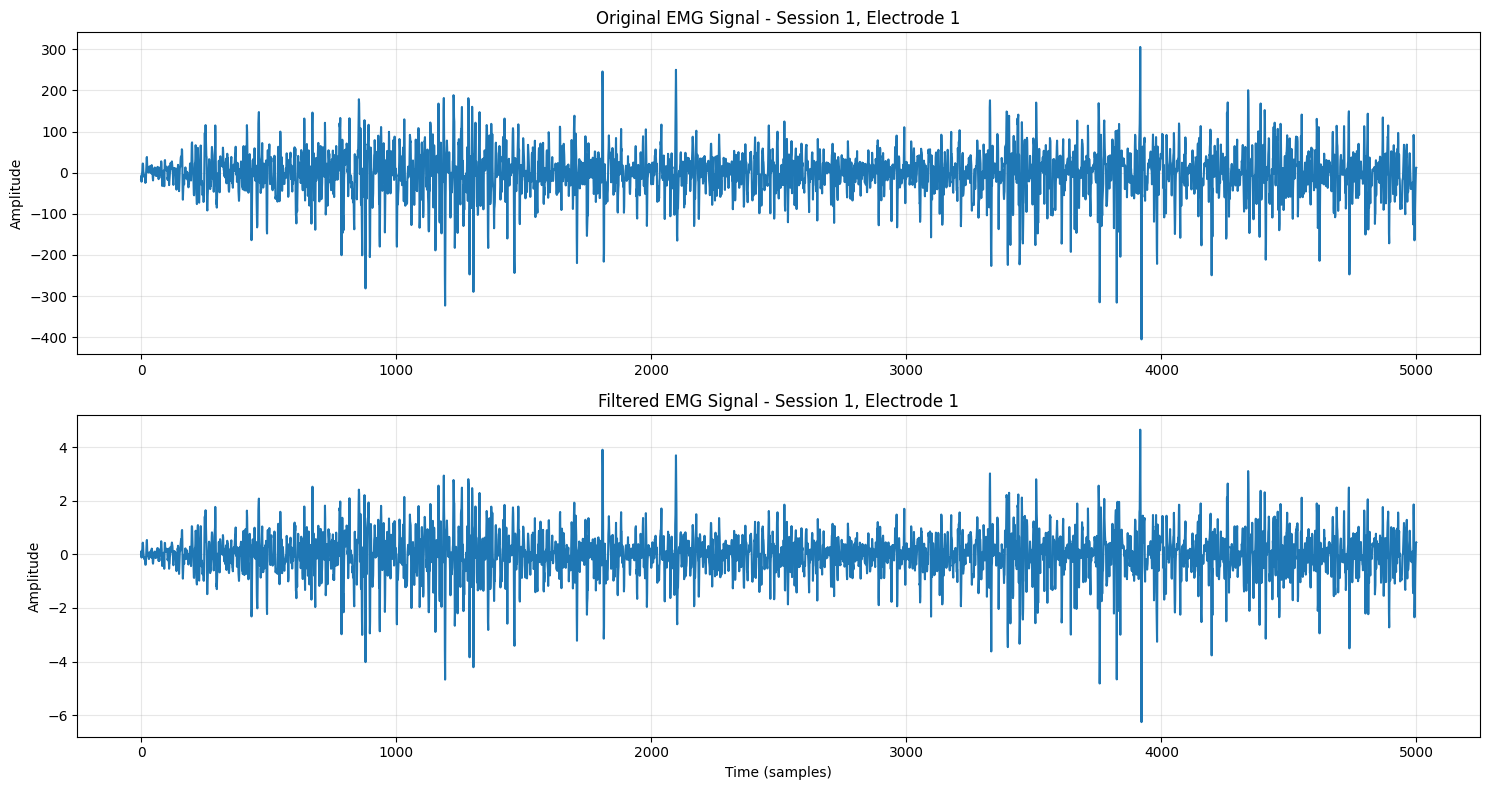

Preprocessing completed in 3.42 seconds

Step 3: Creating windows with overlap...
Window size: 500, Overlap: 50%, Step size: 250
First few window indices to verify 50% overlap:
Window 1: Session 1, Samples 1-500
Window 2: Session 1, Samples 251-750
Window 3: Session 1, Samples 501-1000
Window 4: Session 1, Samples 751-1250
Window 5: Session 1, Samples 1001-1500
Window creation completed in 9.45 seconds
Created 5395 windows with 50% overlap
X_windows shape: (5395, 8, 500)
y_windows shape: (5395, 51, 500)
Target values shape: (5395, 51)

Step 5: Extracting features...
Extracted features shape: (5395, 64)
Number of features: 64
Feature types: ['MAV', 'RMS', 'VAR', 'STD', 'ZC', 'MPR', 'SSC', 'WL']

Performing feature selection and model comparison...

Creating leave-one-session-out cross-validation splits:
Split 1: 4316 training windows, 1079 test windows
Split 2: 4316 training windows, 1079 test windows
Split 3: 4316 training windows, 1079 test windows
Split 4: 4316 training windows, 1079

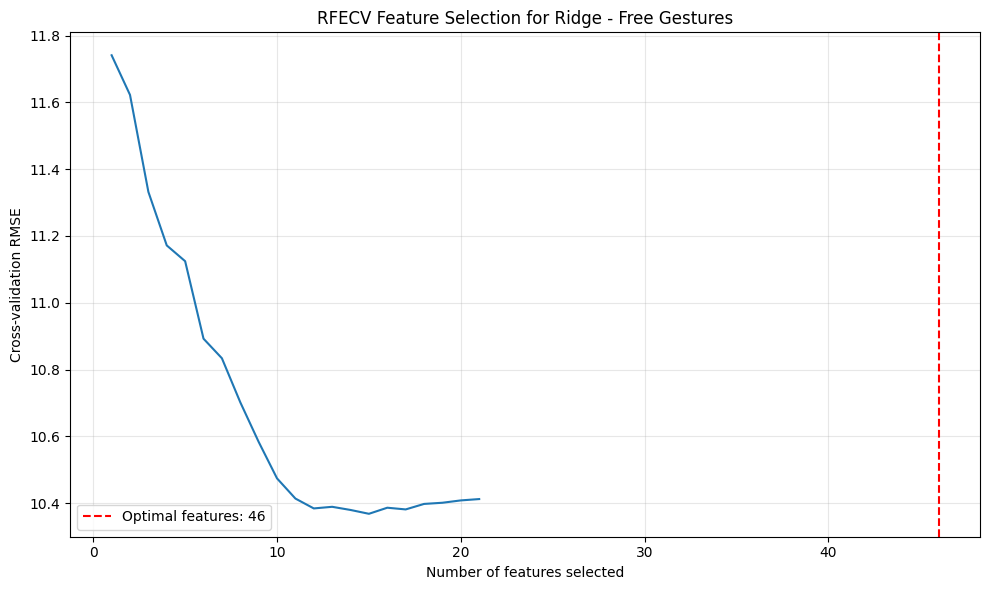


Feature selection for Lasso using RFECV...
  Selected features: ['E1_MAV', 'E1_RMS', 'E1_VAR', 'E1_STD', 'E1_ZC', 'E1_WL', 'E2_MAV', 'E2_VAR', 'E2_STD', 'E2_WL']... (showing first 10)
  Optimal number of features: 43
  Time taken: 381.25 seconds


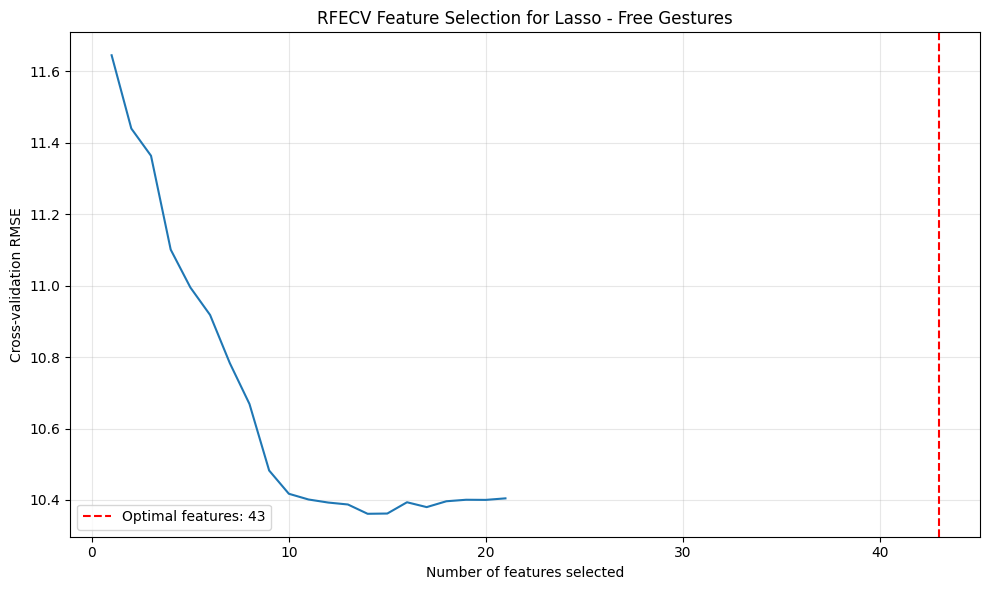


Feature selection for RandomForest using RFECV...
  Selected features: ['E1_MAV', 'E1_STD', 'E2_WL', 'E3_MAV', 'E4_STD', 'E4_WL', 'E5_WL', 'E6_RMS', 'E6_WL', 'E7_RMS']... (showing first 10)
  Optimal number of features: 13
  Time taken: 1252.00 seconds


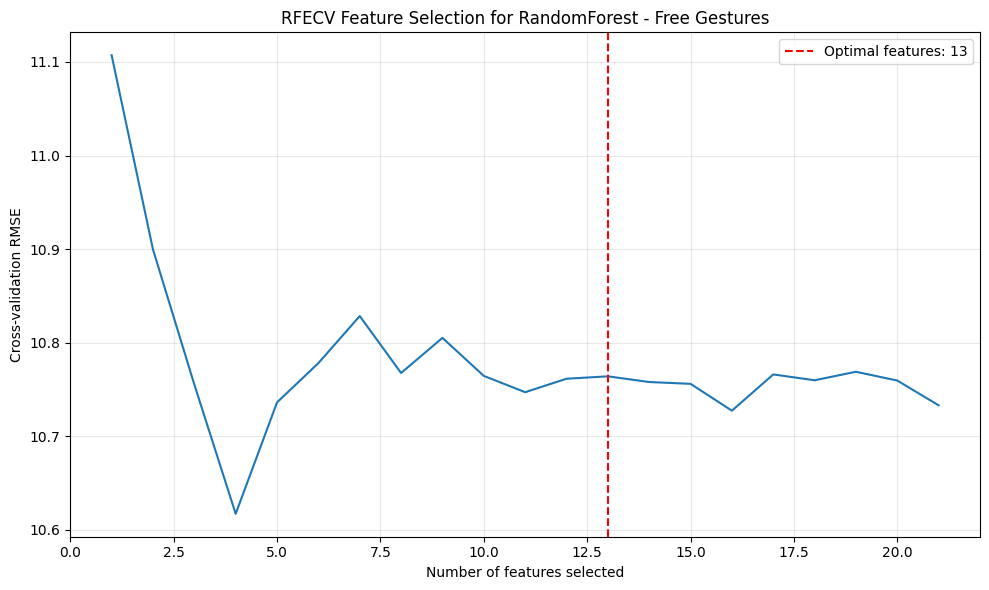


B. Performing Feature Importance Thresholding...

Feature importance analysis for Ridge...
  Using absolute coefficient values for feature ranking
  Top 10 features: ['E2_WL', 'E1_MAV', 'E3_MAV', 'E6_WL', 'E7_WL', 'E4_VAR', 'E3_STD', 'E3_RMS', 'E3_VAR', 'E6_MAV']
  Time taken: 0.06 seconds


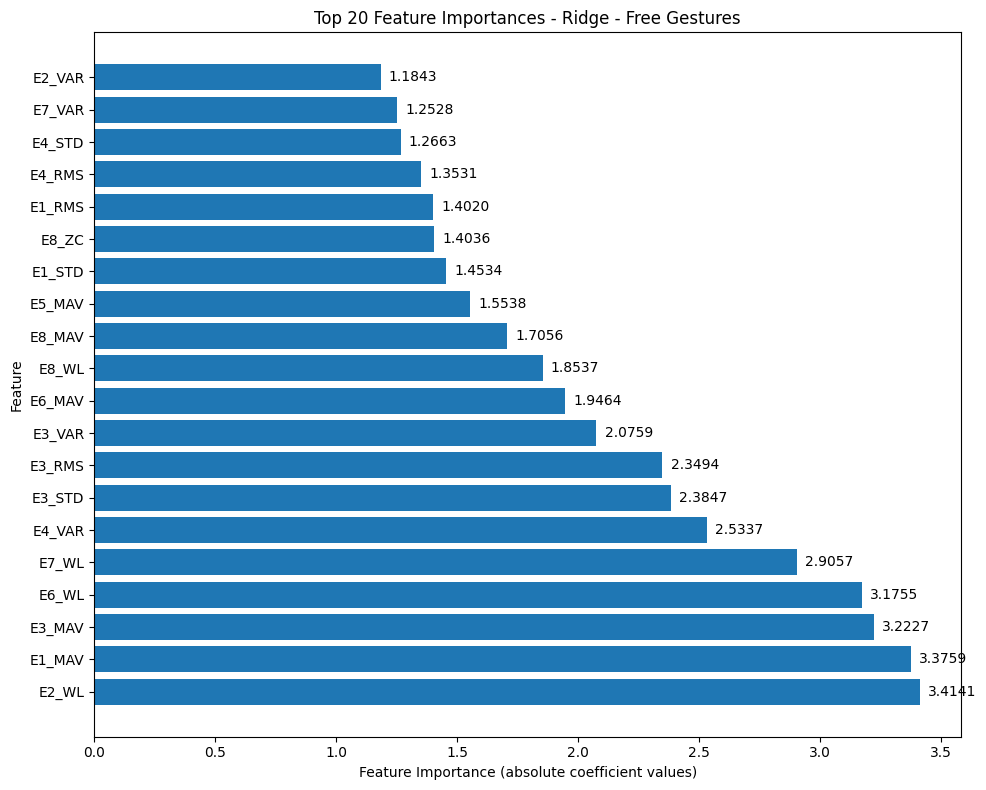


Finding optimal importance threshold for Ridge...
  Testing top 5 features...
    Average RMSE with top 5 features: 10.9366
    Average NMSE with top 5 features: 0.9591
  Testing top 10 features...
    Average RMSE with top 10 features: 10.9121
    Average NMSE with top 10 features: 0.9540
  Testing top 20 features...
    Average RMSE with top 20 features: 10.3300
    Average NMSE with top 20 features: 0.8575
  Testing top 40 features...
    Average RMSE with top 40 features: 10.3197
    Average NMSE with top 40 features: 0.8599
  Testing top 60 features...
    Average RMSE with top 60 features: 10.4435
    Average NMSE with top 60 features: 0.8801
  Testing top 64 features...
    Average RMSE with top 64 features: 10.4671
    Average NMSE with top 64 features: 0.8842
  Selected features: ['E2_WL', 'E1_MAV', 'E3_MAV', 'E6_WL', 'E7_WL', 'E4_VAR', 'E3_STD', 'E3_RMS', 'E3_VAR', 'E6_MAV']... (showing first 10)
  Optimal number of features for Ridge: 40


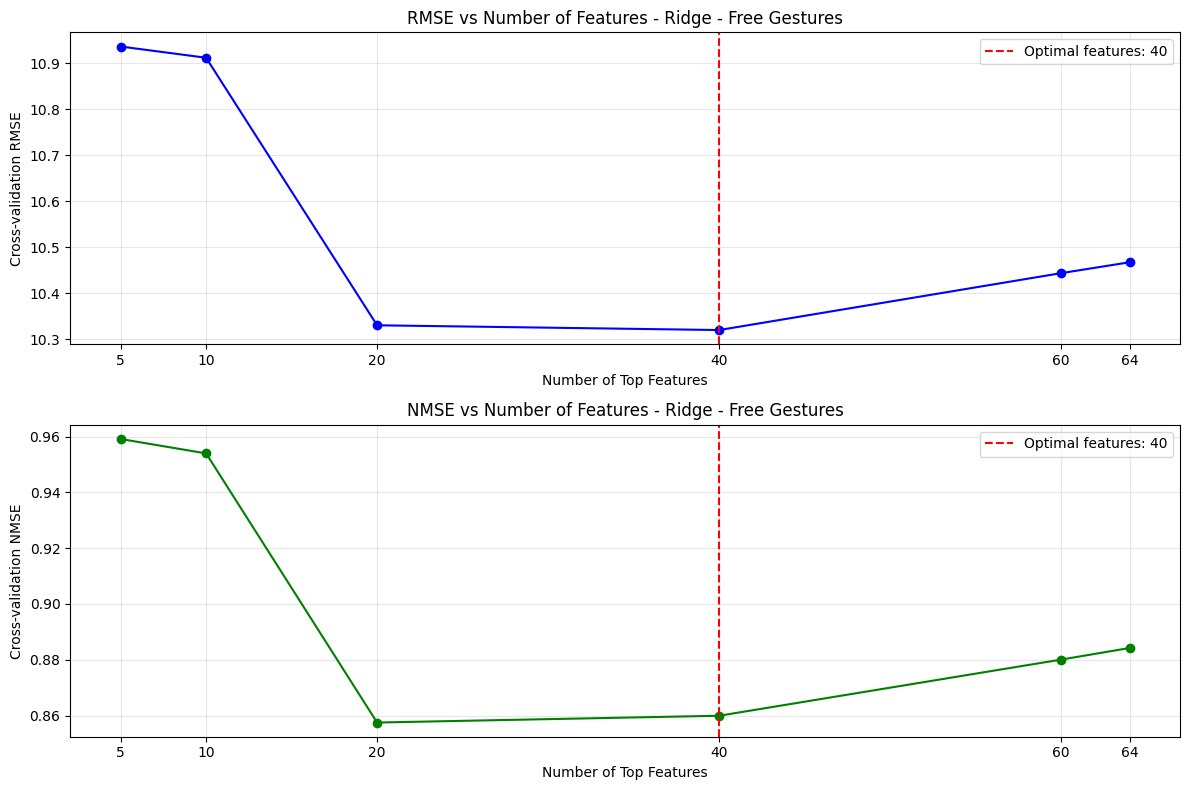


Feature importance analysis for Lasso...
  Using absolute coefficient values for feature ranking
  Top 10 features: ['E2_WL', 'E6_WL', 'E7_WL', 'E4_VAR', 'E1_MAV', 'E3_MAV', 'E3_RMS', 'E3_VAR', 'E4_STD', 'E3_STD']
  Time taken: 12.24 seconds


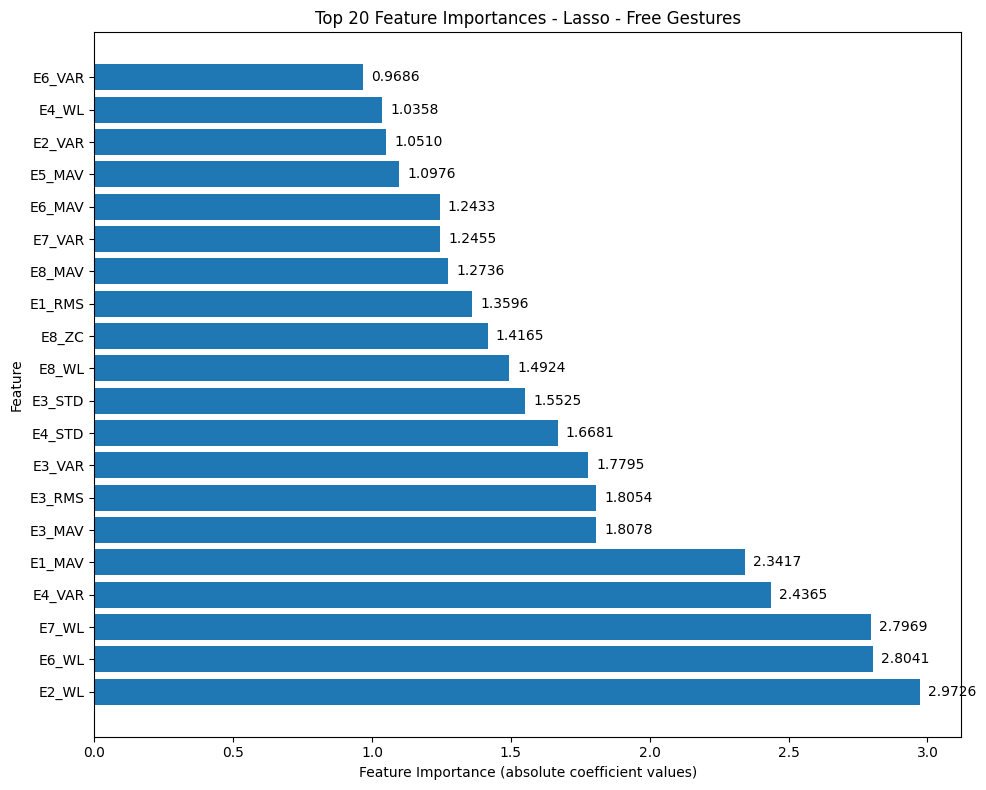


Finding optimal importance threshold for Lasso...
  Testing top 5 features...
    Average RMSE with top 5 features: 10.9690
    Average NMSE with top 5 features: 0.9661
  Testing top 10 features...
    Average RMSE with top 10 features: 10.7626
    Average NMSE with top 10 features: 0.9287
  Testing top 20 features...
    Average RMSE with top 20 features: 10.2776
    Average NMSE with top 20 features: 0.8497
  Testing top 40 features...
    Average RMSE with top 40 features: 10.3042
    Average NMSE with top 40 features: 0.8565
  Testing top 60 features...
    Average RMSE with top 60 features: 10.4454
    Average NMSE with top 60 features: 0.8803
  Testing top 64 features...
    Average RMSE with top 64 features: 10.4540
    Average NMSE with top 64 features: 0.8818
  Selected features: ['E2_WL', 'E6_WL', 'E7_WL', 'E4_VAR', 'E1_MAV', 'E3_MAV', 'E3_RMS', 'E3_VAR', 'E4_STD', 'E3_STD']... (showing first 10)
  Optimal number of features for Lasso: 20


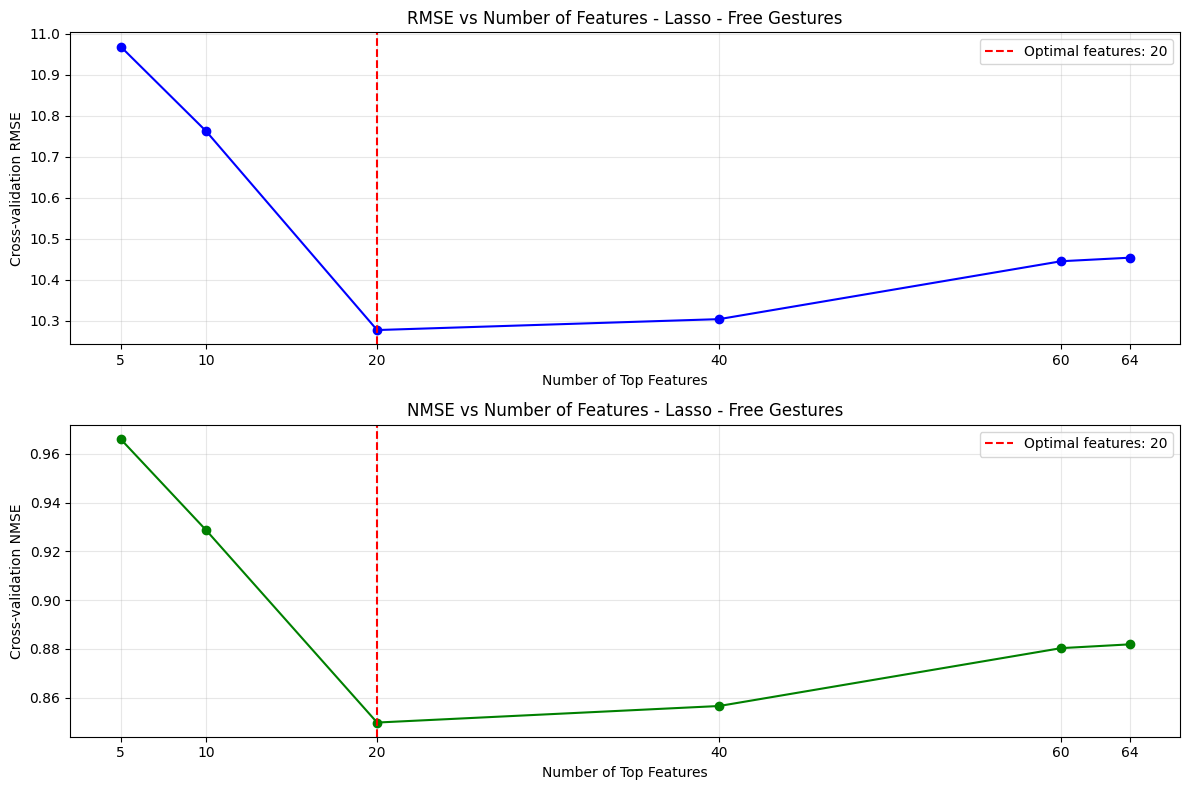


Feature importance analysis for RandomForest...
  Using feature importances for feature ranking
  Top 10 features: ['E4_WL', 'E7_WL', 'E1_MAV', 'E6_WL', 'E7_ZC', 'E8_ZC', 'E5_WL', 'E2_WL', 'E8_SSC', 'E4_MPR']
  Time taken: 63.05 seconds


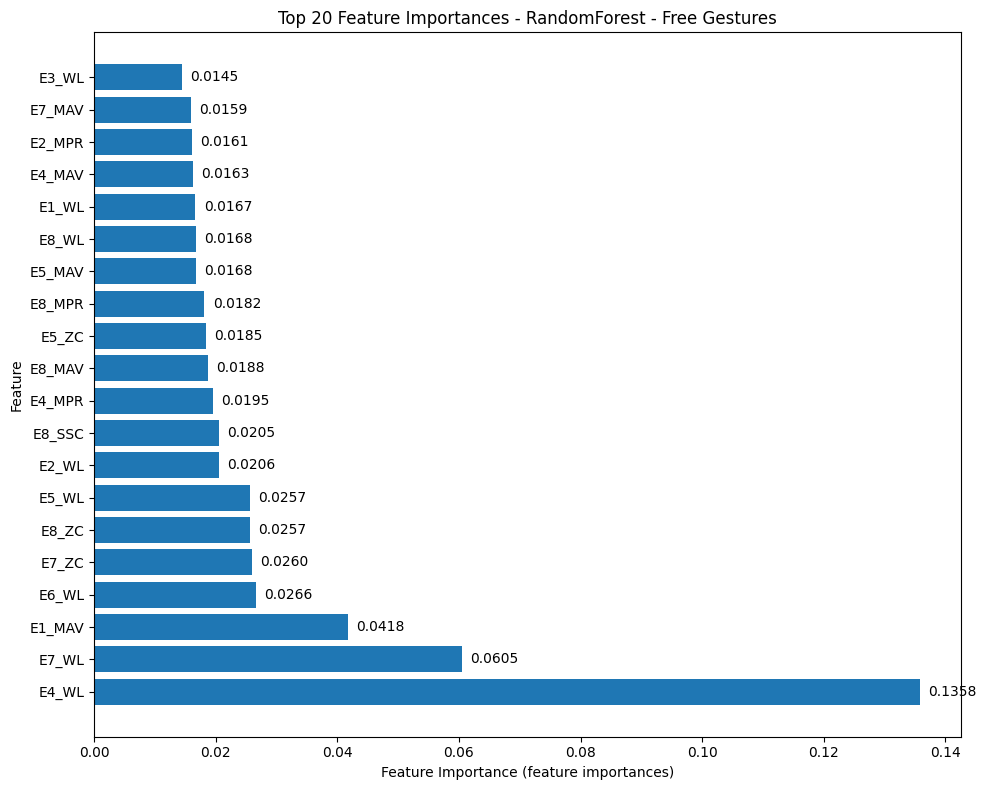


Finding optimal importance threshold for RandomForest...
  Testing top 5 features...
    Average RMSE with top 5 features: 11.0247
    Average NMSE with top 5 features: 0.9858
  Testing top 10 features...
    Average RMSE with top 10 features: 10.6340
    Average NMSE with top 10 features: 0.9165
  Testing top 20 features...
    Average RMSE with top 20 features: 10.5753
    Average NMSE with top 20 features: 0.9075
  Testing top 40 features...
    Average RMSE with top 40 features: 10.6845
    Average NMSE with top 40 features: 0.9270
  Testing top 60 features...
    Average RMSE with top 60 features: 10.6673
    Average NMSE with top 60 features: 0.9234
  Testing top 64 features...
    Average RMSE with top 64 features: 10.6539
    Average NMSE with top 64 features: 0.9212
  Selected features: ['E4_WL', 'E7_WL', 'E1_MAV', 'E6_WL', 'E7_ZC', 'E8_ZC', 'E5_WL', 'E2_WL', 'E8_SSC', 'E4_MPR']... (showing first 10)
  Optimal number of features for RandomForest: 20


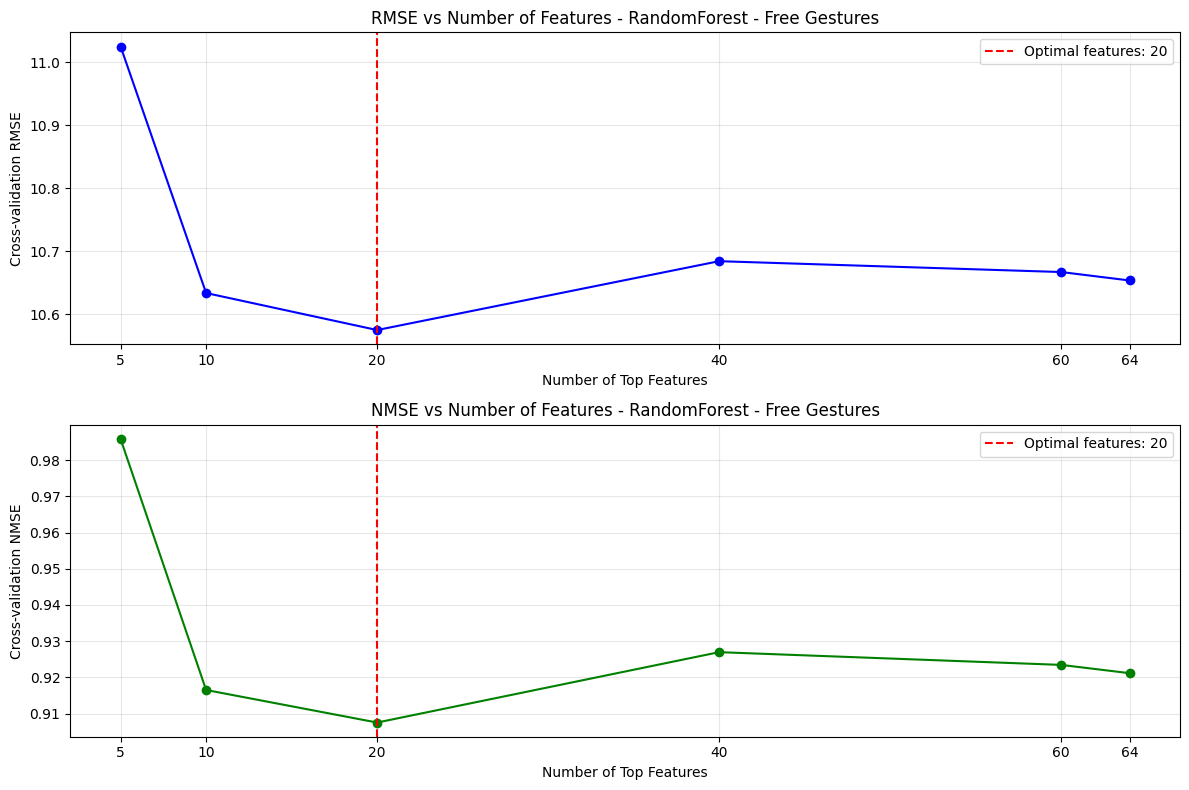


Comparing feature selection methods and determining best configuration...
  Ridge with RFECV: 46 features, RMSE = 10.3132, NMSE = 0.8583
  Lasso with RFECV: 43 features, RMSE = 10.3009, NMSE = 0.8559
  RandomForest with RFECV: 13 features, RMSE = 10.6324, NMSE = 0.9155
  Ridge with Importance: 40 features, RMSE = 10.3197, NMSE = 0.8599
  Lasso with Importance: 20 features, RMSE = 10.2776, NMSE = 0.8497
  RandomForest with Importance: 20 features, RMSE = 10.5753, NMSE = 0.9075

Best feature selection configuration:
  Model: Lasso
  Selection Method: Importance
  Number of Features: 20
  Cross-Validation RMSE: 10.2776
  Cross-Validation NMSE: 0.8497


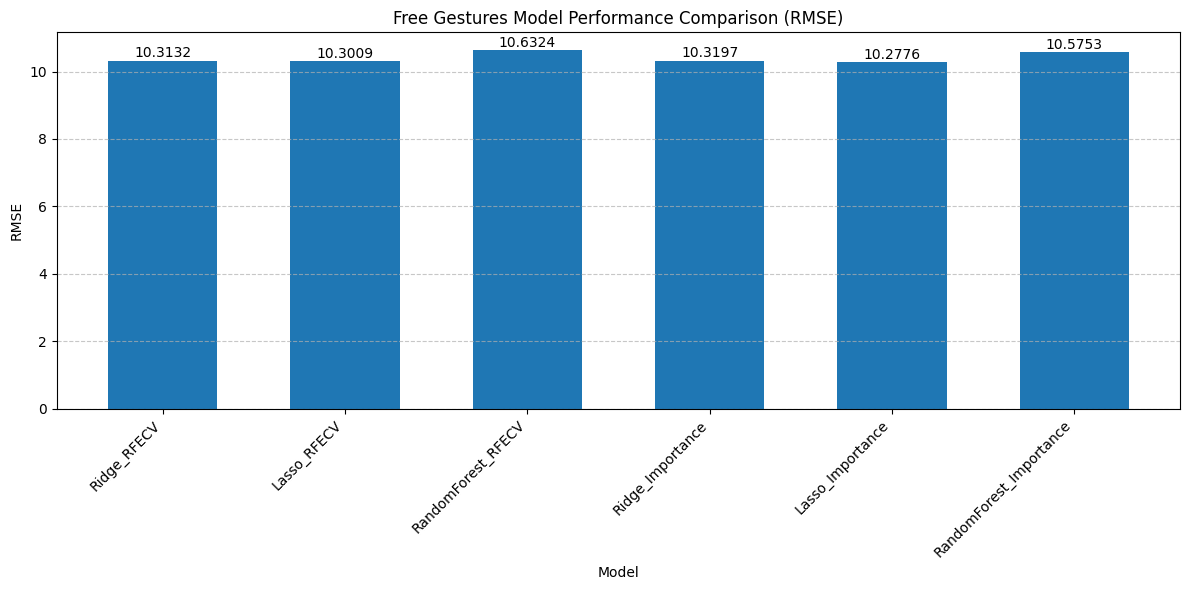

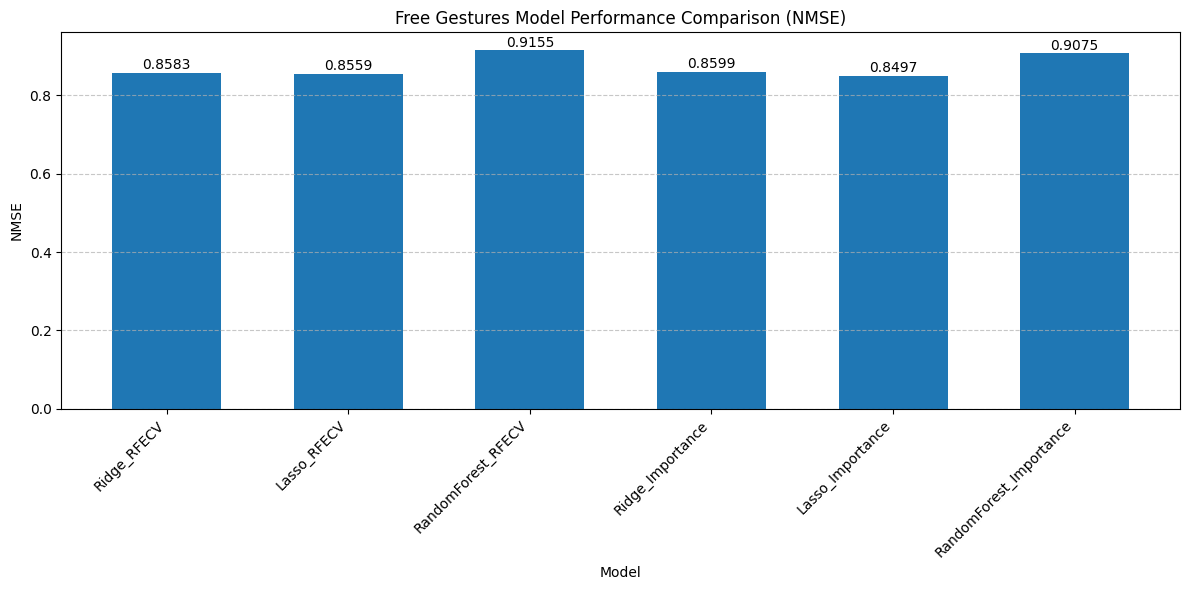


Step 7: Comparing basic regression models...
Extracting features from windows...
Extracted features shape: (5395, 64)

Creating leave-one-session-out cross-validation splits:
Split 1: 4316 training windows, 1079 test windows
Split 2: 4316 training windows, 1079 test windows
Split 3: 4316 training windows, 1079 test windows
Split 4: 4316 training windows, 1079 test windows
Split 5: 4316 training windows, 1079 test windows
Target values shape: (5395, 51)

Evaluating Ridge Regression...
  Fold 1/5: Training on 4316 samples, testing on 1079 samples
    RMSE = 9.8662, NMSE = 0.8581
  Fold 2/5: Training on 4316 samples, testing on 1079 samples
    RMSE = 12.9407, NMSE = 1.0294
  Fold 3/5: Training on 4316 samples, testing on 1079 samples
    RMSE = 9.7076, NMSE = 0.6178
  Fold 4/5: Training on 4316 samples, testing on 1079 samples
    RMSE = 9.9089, NMSE = 0.9830
  Fold 5/5: Training on 4316 samples, testing on 1079 samples
    RMSE = 9.9138, NMSE = 0.9330
  Average RMSE across all folds: 1

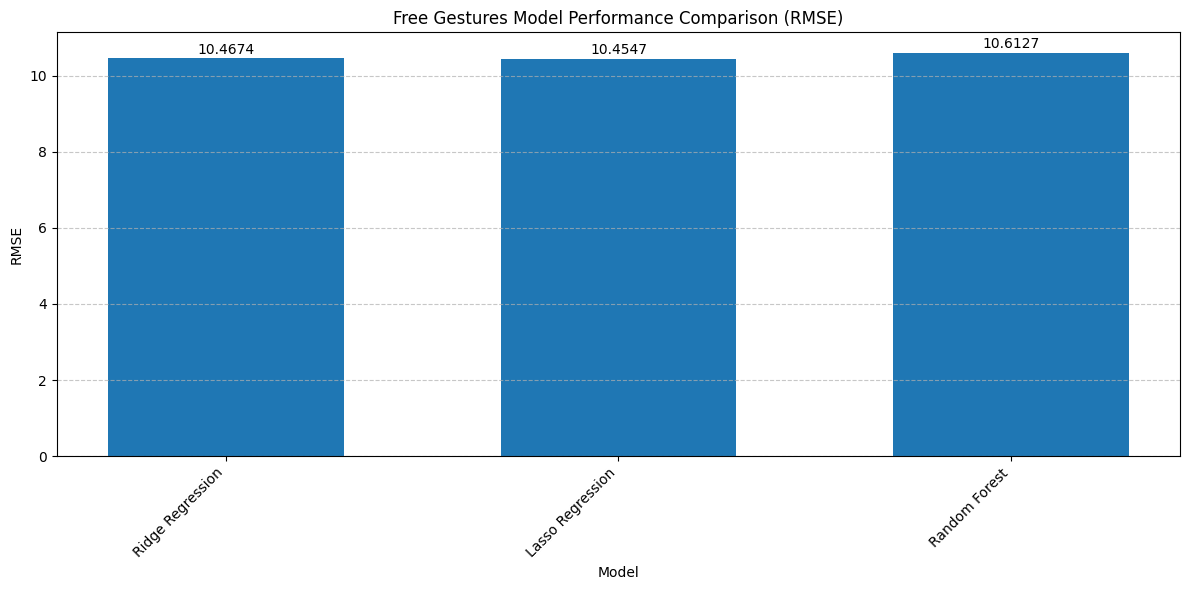

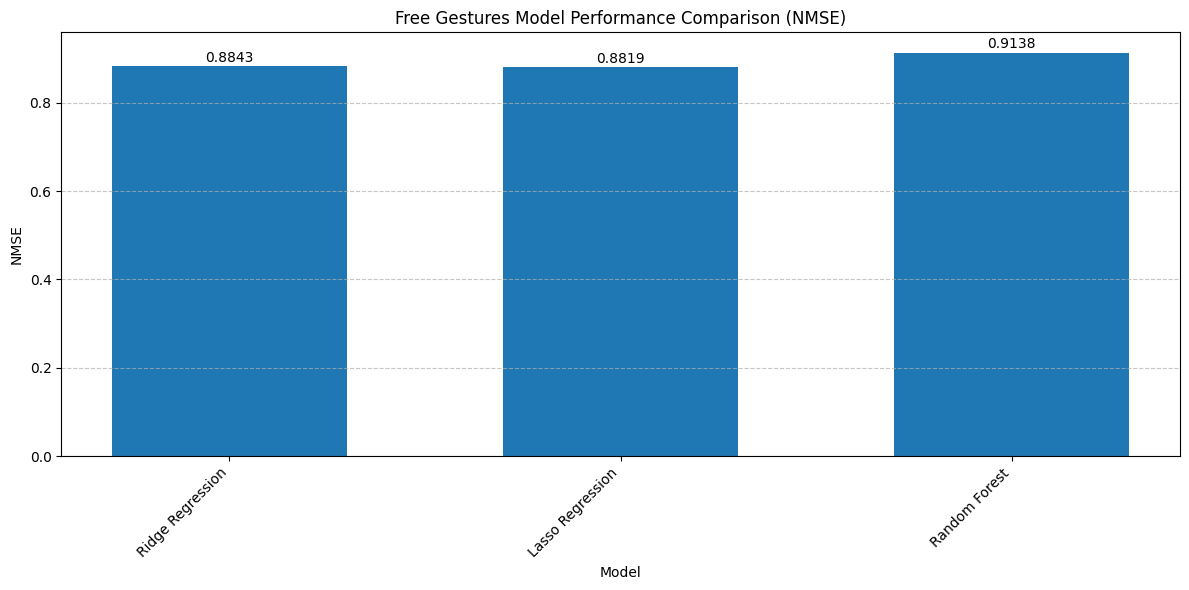


Step 8: Training final model with selected features...
Training completed in 12.77 seconds

Step 9: Generating predictions for test data...
Applying bandpass and notch filters to EMG signals...
Normalizing EMG channels...
Generating predictions for 1540 test windows...
Processing session 1/5...
Applying bandpass and notch filters to EMG signals...
Normalizing EMG channels...
Applying bandpass and notch filters to EMG signals...
Normalizing EMG channels...
  Processed 100/1540 windows (6.5%) - Elapsed: 0.2s
Applying bandpass and notch filters to EMG signals...
Normalizing EMG channels...
Applying bandpass and notch filters to EMG signals...
Normalizing EMG channels...
  Processed 200/1540 windows (13.0%) - Elapsed: 0.4s
Applying bandpass and notch filters to EMG signals...
Normalizing EMG channels...
Applying bandpass and notch filters to EMG signals...
Normalizing EMG channels...
  Processed 300/1540 windows (19.5%) - Elapsed: 0.6s
Applying bandpass and notch filters to EMG signals...

In [8]:
#--------------------------------------------------------------
# 7. Main Pipeline
#--------------------------------------------------------------

# Main pipeline for free gestures dataset
if __name__ == "__main__":
    # Settings
    window_size = 500
    overlap_percent = 50
    apply_filtering = True  # Apply signal filtering 
    normalize = True        # Apply normalization
    
    print("Processing free gestures dataset...")
    
    # Check if data is loaded
    if 'freemoves_X' not in globals() or 'freemoves_y' not in globals():
        print("Loading free gestures datasets...")
        freemoves_X = np.load('freemoves_dataset_X.npy')
        freemoves_y = np.load('freemoves_dataset_y.npy')
        print(f"Loaded freemoves_X with shape: {freemoves_X.shape}")
        print(f"Loaded freemoves_y with shape: {freemoves_y.shape}")
    
    # 1. Check data quality
    print("\nStep 1: Checking EMG data quality...")
    quality_report = check_emg_data_quality(freemoves_X)
    print(f"NaN values: {quality_report['nan_count']}")
    print(f"Infinite values: {quality_report['inf_count']}")
    
    if 'electrode_stats' in quality_report:
        print("\nElectrode statistics:")
        for stats in quality_report['electrode_stats']:
            print(f"Electrode {stats['electrode']}: Mean={stats['mean']:.2f}, STD={stats['std']:.2f}, SNR={stats['signal_to_noise']:.2f}")
    
    # 2. Apply preprocessing (filtering and normalization)
    print("\nStep 2: Applying signal preprocessing...")
    start_time = time.time()
    
    # Use the enhanced preprocessing function with visualization
    processed_X = preprocess_emg_data(
        freemoves_X, 
        apply_filtering=apply_filtering,
        normalize=normalize,
        visualize=True,  # Set to True to visualize the filtering effect
        session_id=0,    # First session
        electrode_id=0,  # First electrode
        time_segment=slice(0, 5000)  # First 5000 samples
    )
    
    print(f"Preprocessing completed in {time.time() - start_time:.2f} seconds")
    
    # 3. Create windows with overlap
    print("\nStep 3: Creating windows with overlap...")
    start_time = time.time()
    X_windows, y_windows, window_indices = create_matching_windows(
        processed_X, freemoves_y, window_size=window_size, overlap_percent=overlap_percent
    )
    print(f"Window creation completed in {time.time() - start_time:.2f} seconds")
    print(f"Created {len(window_indices)} windows with {overlap_percent}% overlap")
    print(f"X_windows shape: {X_windows.shape}")
    print(f"y_windows shape: {y_windows.shape}")

    
    # 4. Calculate mean joint angle in each window as the target
    y_targets = np.mean(y_windows, axis=2)
    print(f"Target values shape: {y_targets.shape}")
    
    # 5. Extract features
    print("\nStep 5: Extracting features...")
    feature_extractor = EMGFeatureExtractor() 
    X_features = feature_extractor.transform(X_windows)
    feature_names = feature_extractor.get_feature_names()
    print(f"Extracted features shape: {X_features.shape}")
    print(f"Number of features: {len(feature_names)}")
    print(f"Feature types: {feature_extractor.all_features}")
    
    # 6. Feature selection and model comparison
    best_config, best_features, feature_selection_results, all_models_results = select_optimal_features(
        X_features, 
        y_targets, 
        window_indices, 
        n_sessions=freemoves_X.shape[0],
        feature_names=feature_names
    )
    
    # 7. Compare basic regression models (alternative approach)
    print("\nStep 7: Comparing basic regression models...")
    best_basic_model, basic_results = compare_regression_models(
        X_windows, 
        y_targets, 
        window_indices, 
        n_sessions=freemoves_X.shape[0]
    )
    
    # 8. Train final model with best feature selection
    print(f"\nStep 8: Training final model with selected features...")
    start_time = time.time()
    
    # Create feature extractor with optimal features selected
    optimal_feature_extractor = EMGFeatureExtractor(selected_features=best_features)
    
    # Create final model pipeline based on best configuration
    if best_config['Model'] == 'Ridge':
        final_model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Ridge(alpha=1.0))
        ])
    elif best_config['Model'] == 'Lasso':
        final_model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Lasso(alpha=0.01, max_iter=10000))
        ])
    else:
        final_model = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
        ])
    
    # Extract features with optimal selection
    X_final = optimal_feature_extractor.transform(X_windows)
    
    # Train final model
    final_model.fit(X_final, y_targets)
    print(f"Training completed in {time.time() - start_time:.2f} seconds")
    
    # 9. Generate predictions for test data (if available)
    if 'freemoves_testset_X' not in globals():
        try:
            print("\nLoading freemoves test data...")
            freemoves_testset_X = np.load('freemoves_testset_X.npy')
            print(f"Loaded freemoves_testset_X with shape: {freemoves_testset_X.shape}")
        except:
            print("Test data file 'freemoves_testset_X.npy' not found.")
    
    if 'freemoves_testset_X' in globals():
        print("\nStep 9: Generating predictions for test data...")
        start_time = time.time()
        
        # Generate predictions using the final model
        test_predictions = predict_test_data(
            final_model, 
            freemoves_testset_X, 
            apply_filtering=apply_filtering,
            normalize=normalize,
            batch_size=50,
            selected_features=best_features
        )
        
        print(f"Generated predictions shape: {test_predictions.shape}")
        print(f"Prediction completed in {time.time() - start_time:.2f} seconds")
        
        # Save predictions to CSV
        print("\nSaving predictions to freemoves_predictions.csv...")
        np.savetxt('freemoves_predictions.csv', test_predictions, delimiter=',')
        print("Predictions saved successfully!")
    else:
        print("\nTest data not found. If you have the test data, please load it with:")
        print("freemoves_testset_X = np.load('freemoves_testset_X.npy')")